In [1]:
import geopandas as gpd
import pandas as pd

basline_blocks = gpd.read_file('./data/gatchina/blocks_agg_with_indicators.geojson')
basline_blocks.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,is_living,...,area_accessibility,fsi,gsi,mxi,l,osr,share_living,share_non_living,morphotype,geometry
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,6.0,...,10.063987,0.012109,0.008829,0.091908,1.371459,81.852753,0.126048,1.245411,individual residential,"POLYGON ((30.09367 59.55207, 30.09375 59.55215..."
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,13.0,...,10.210398,0.212156,0.036428,0.712492,5.824002,4.541808,4.149554,1.674447,mid-rise,"POLYGON ((30.09448 59.56164, 30.09448 59.56164..."
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,15.0,...,8.669212,0.303551,0.056576,0.786029,5.365401,3.107955,4.217362,1.148039,mid-rise,"POLYGON ((30.12546 59.58002, 30.12541 59.57998..."
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,2.0,...,7.467434,0.173716,0.075903,0.198114,2.288643,5.319595,0.453413,1.835230,low-rise model,"POLYGON ((30.12501 59.56588, 30.12497 59.56582..."
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,2.0,...,8.285434,0.156696,0.071648,0.095598,2.187029,5.924533,0.209075,1.977953,low-rise model,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,..."


In [2]:
cols = [
    'residential','business','recreation','industrial','transport','special',
    'agriculture','land_use','share','footprint_area','build_floor_area',
    'living_area','non_living_area','population','site_area','fsi','gsi',
    'mxi','l','morphotype','area_accessibility', 'geometry'
]
basline_blocks = basline_blocks[cols]


In [3]:
from catboost import CatBoostRegressor
model = CatBoostRegressor()
model.load_model('./data/catboost_model.cbm')  # модель на лог-цене
print(len(model.feature_names_))

121


In [4]:
feature_cols = [
'residential','business','recreation','industrial','transport','special',
'agriculture','land_use','share','footprint_area','build_floor_area',
'living_area','non_living_area','population','site_area','fsi','gsi',
'mxi','l','morphotype','area_accessibility'
]
cat_features = ['land_use', 'morphotype']
numeric_feats = [c for c in feature_cols if c not in cat_features]

In [5]:
basline_blocks['residential'] = basline_blocks['residential'].astype('float64')

In [6]:
from catboost import CatBoostRegressor

from urbanomy.methods.land_value_modeling import LandPriceEstimator

estimator = LandPriceEstimator(
    model=model,
    orig_features=numeric_feats+cat_features,
    categorical_features=cat_features,
    blocks=basline_blocks, #or blocks_198
)
blocks_pred = estimator.predict()

blocks_pred.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,population,site_area,fsi,gsi,mxi,l,morphotype,area_accessibility,geometry,land_value
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,7383.849525,...,30.0,836277.821579,0.012109,0.008829,0.091908,1.371459,individual residential,10.063987,"POLYGON ((30.09367 59.55207, 30.09375 59.55215...",6.833466e+08
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,15304.958732,...,2000.0,420144.041613,0.212156,0.036428,0.712492,5.824002,mid-rise,10.210398,"POLYGON ((30.09448 59.56164, 30.09448 59.56164...",8.727378e+08
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,17141.628200,...,2275.0,302985.560228,0.303551,0.056576,0.786029,5.365401,mid-rise,8.669212,"POLYGON ((30.12546 59.58002, 30.12541 59.57998...",6.121753e+08
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,9453.530183,...,134.0,124546.982903,0.173716,0.075903,0.198114,2.288643,low-rise model,7.467434,"POLYGON ((30.12501 59.56588, 30.12497 59.56582...",1.809802e+08
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,8567.309559,...,56.0,119574.990985,0.156696,0.071648,0.095598,2.187029,low-rise model,8.285434,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,...",1.709968e+08


count       347.000000
mean     134532.459241
std       73884.256473
min           0.000000
25%       64773.223914
50%      149911.559259
75%      200799.237991
max      259942.812036
Name: land_value_per_100m2, dtype: float64


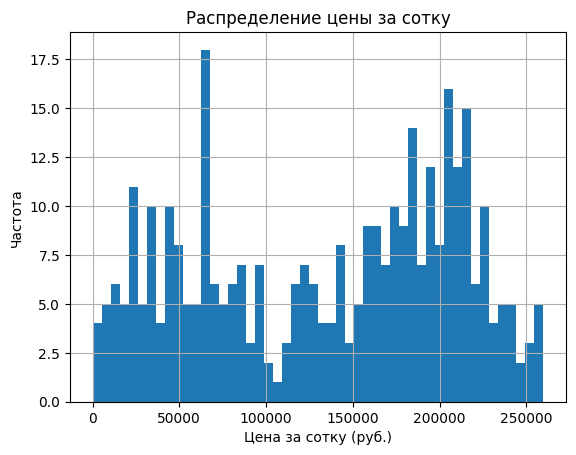

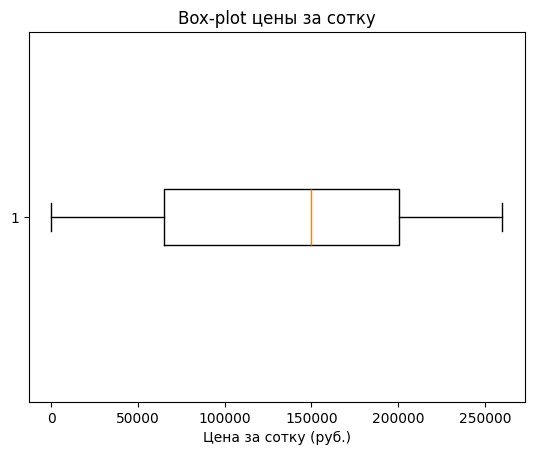

In [7]:
import numpy as np
import matplotlib.pyplot as plt
# 1) Цена за сотку (100 м²)
blocks_pred["land_value_per_100m2"] = blocks_pred["land_value"] / blocks_pred["site_area"] * 100

# 2) Заменяем inf на NaN
blocks_pred = blocks_pred.replace([np.inf, -np.inf], np.nan)
blocks_pred = blocks_pred.fillna(0)

# 3) Удаляем выбросы: оставляем данные до 99-го перцентиля
p99 = blocks_pred["land_value_per_100m2"].quantile(0.99)
blocks_clean = blocks_pred[blocks_pred["land_value_per_100m2"] <= p99].copy()

print(blocks_clean["land_value_per_100m2"].describe())

# 4) Гистограмма после очистки
plt.figure()
blocks_clean["land_value_per_100m2"].dropna().hist(bins=50)
plt.xlabel("Цена за сотку (руб.)")
plt.ylabel("Частота")
plt.title("Распределение цены за сотку")
plt.show()

# 5) Box-plot после очистки
plt.figure()
plt.boxplot(blocks_clean["land_value_per_100m2"].dropna(), vert=False)
plt.xlabel("Цена за сотку (руб.)")
plt.title("Box-plot цены за сотку")
plt.show()



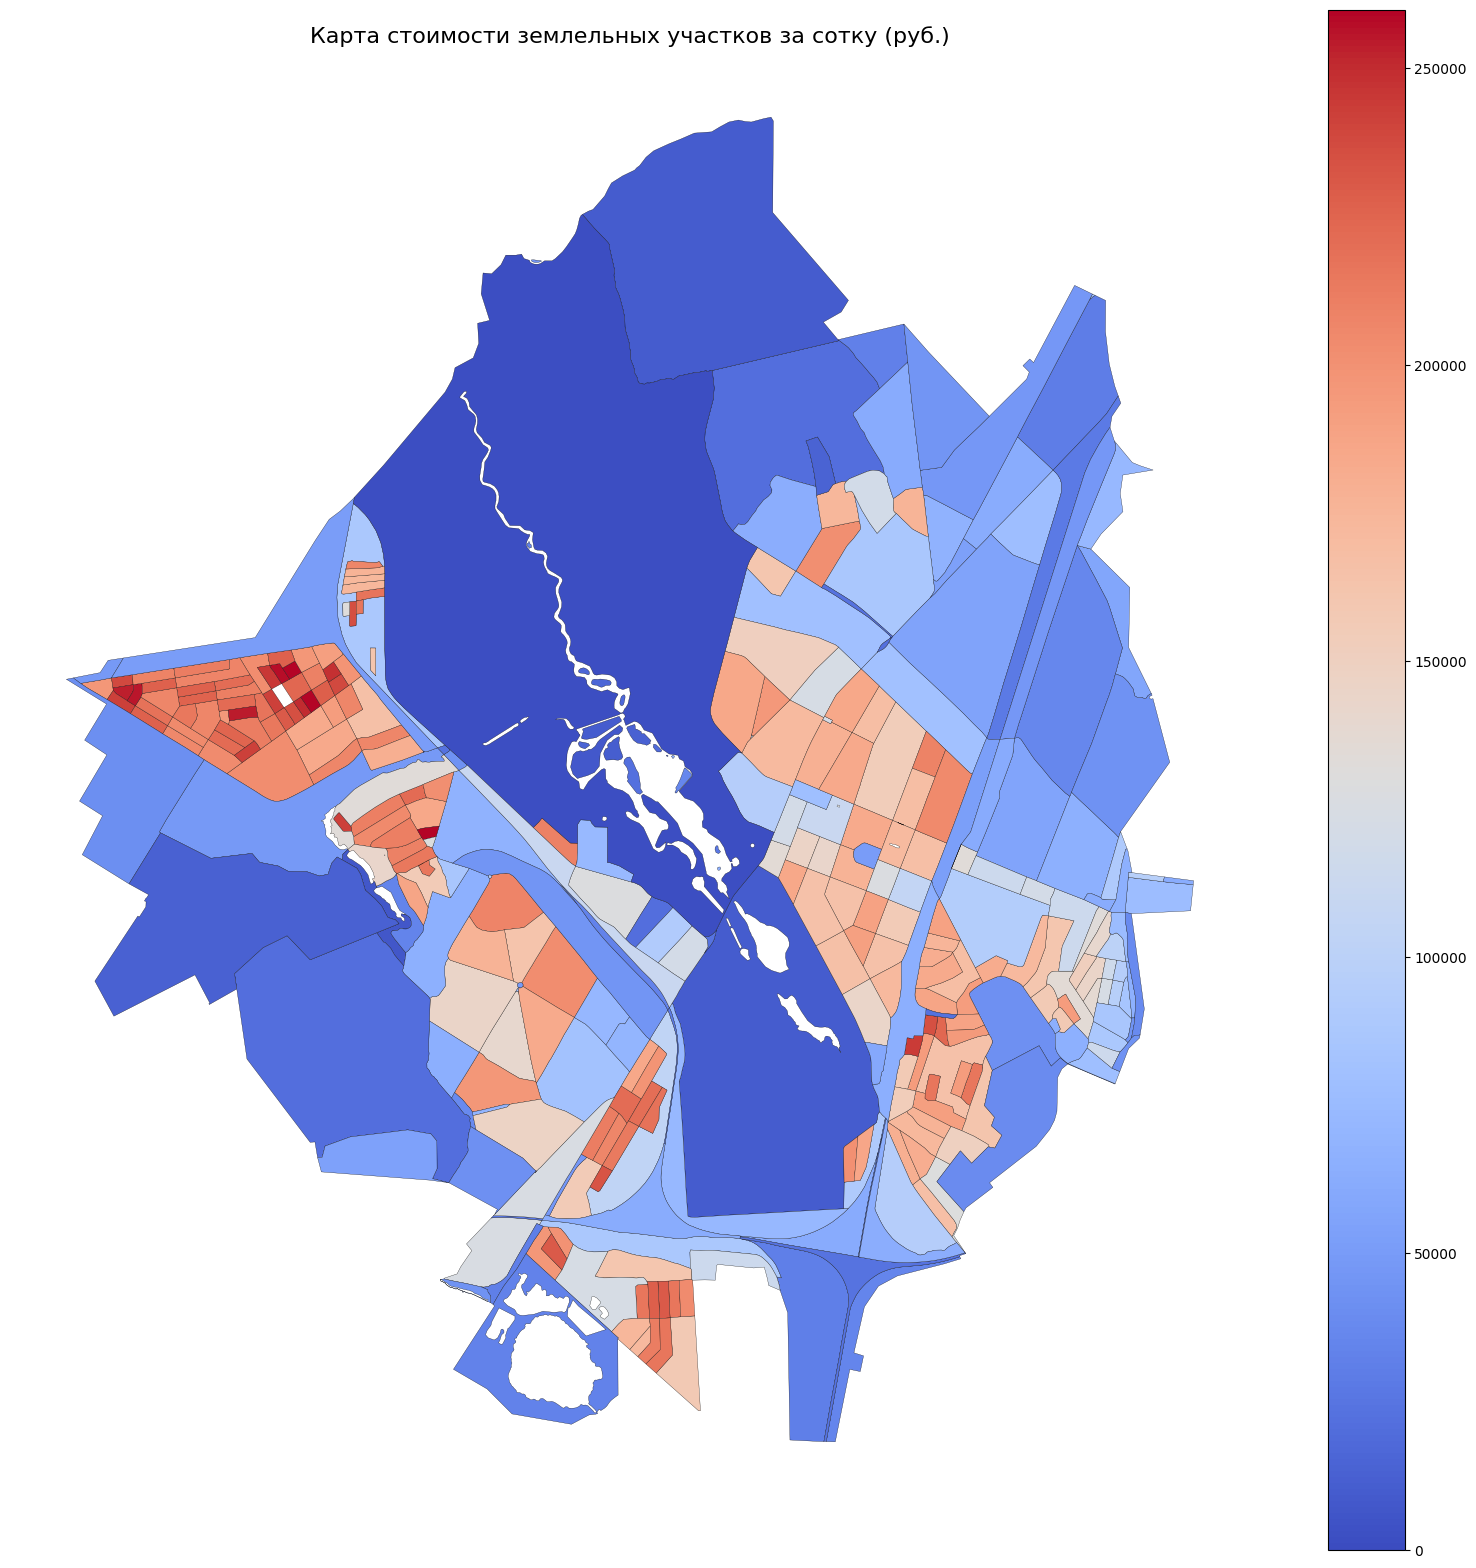

In [8]:
import matplotlib.pyplot as plt

blocks_clean.plot(
    column='land_value_per_100m2',
    legend=True,
    figsize=(20,20),
    cmap='coolwarm',
    edgecolor='black',   # <-- цвет границы
    linewidth=0.2        # <-- толщина границы
).set_axis_off()
plt.title('Карта стоимости землельных участков за сотку (руб.)', fontsize=16)

plt.show()

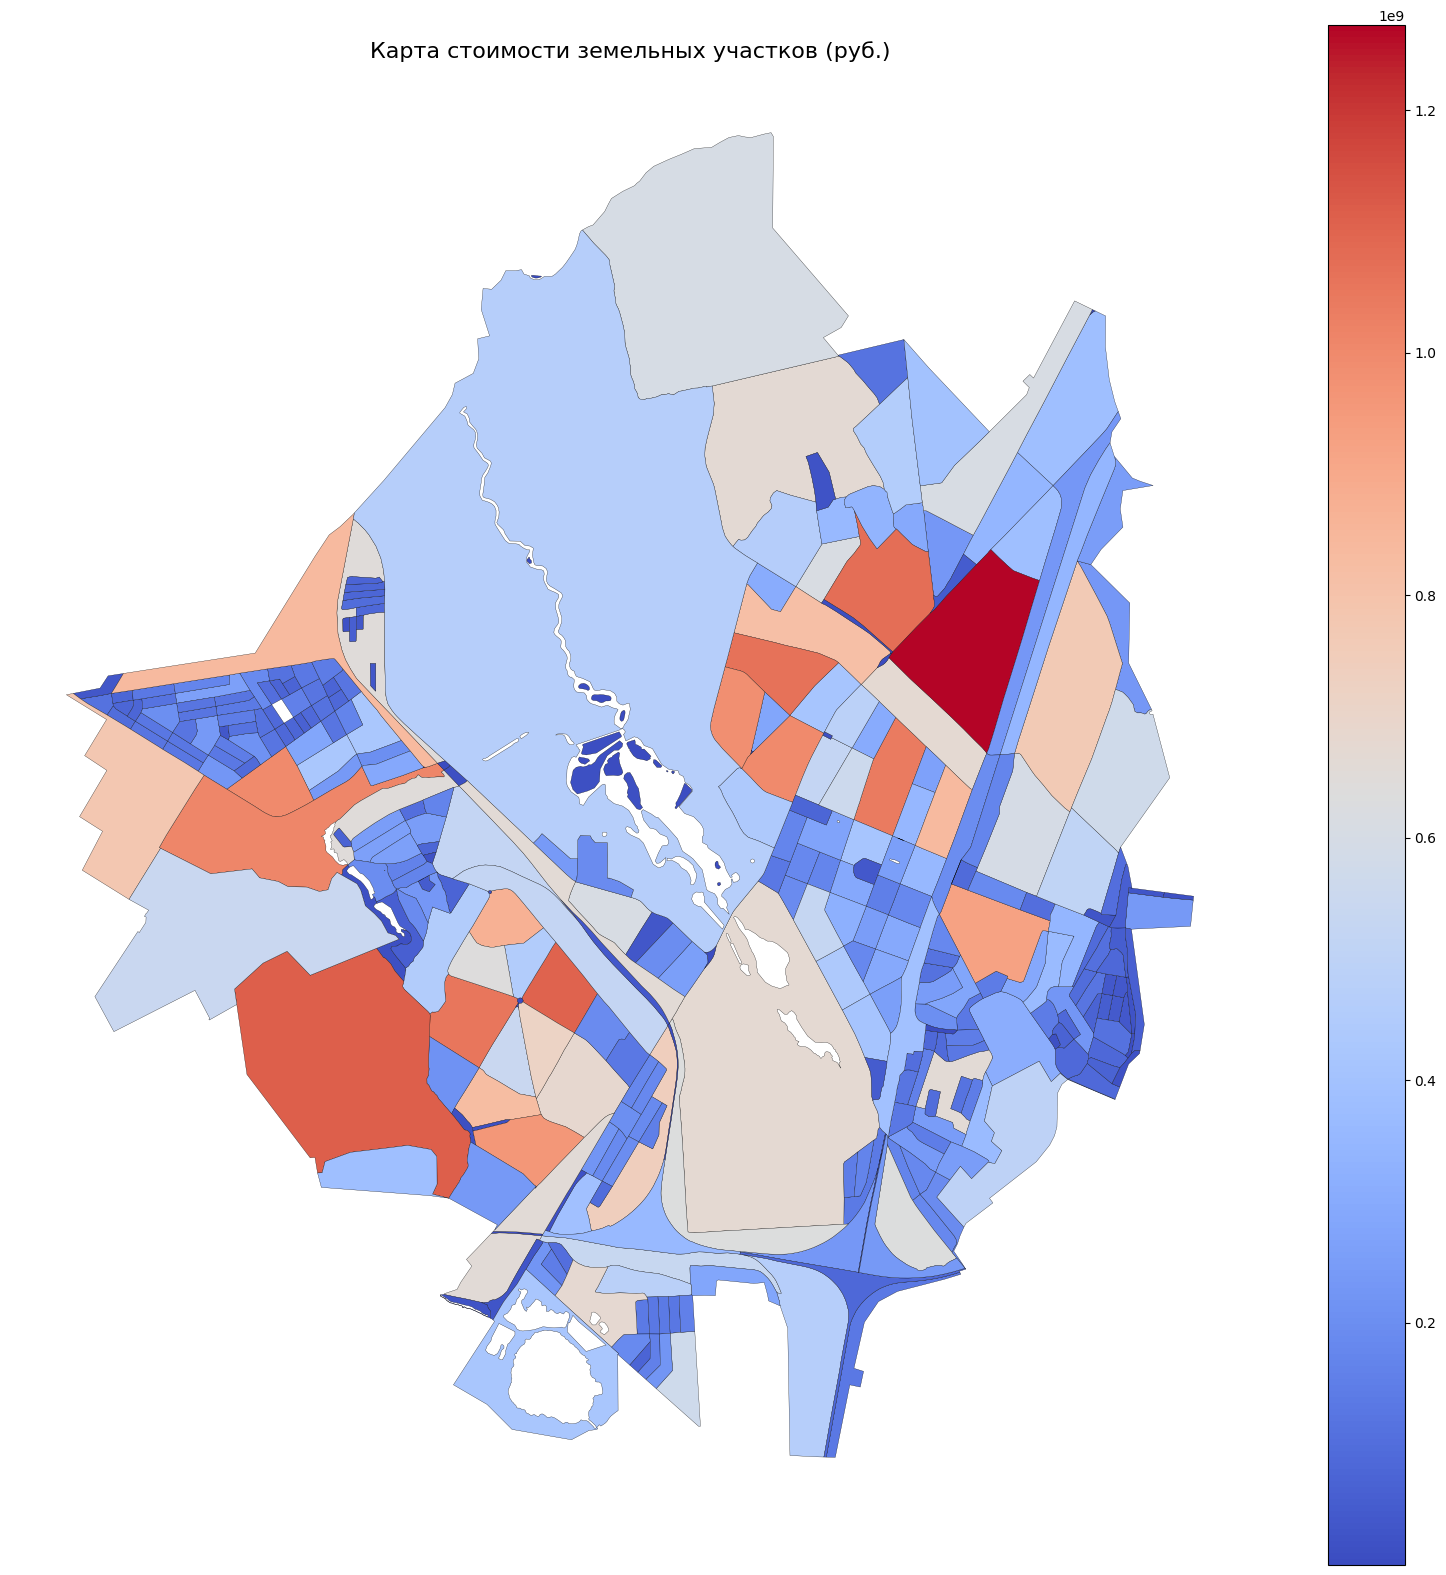

In [9]:
import matplotlib.pyplot as plt

blocks_clean.plot(
    column='land_value',
    legend=True,
    figsize=(20,20),
    cmap='coolwarm',
    edgecolor='black',   # <-- цвет границы
    linewidth=0.2        # <-- толщина границы
).set_axis_off()
plt.title('Карта стоимости земельных участков (руб.)', fontsize=16)

plt.show()

In [10]:
blocks_clean["id"] = blocks_clean.index

In [11]:
# blocks_clean.explore()

/tmp/ipykernel_22446/1807181840.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  blocks_clean.loc[blocks_clean["id"]==87].centroid.plot(


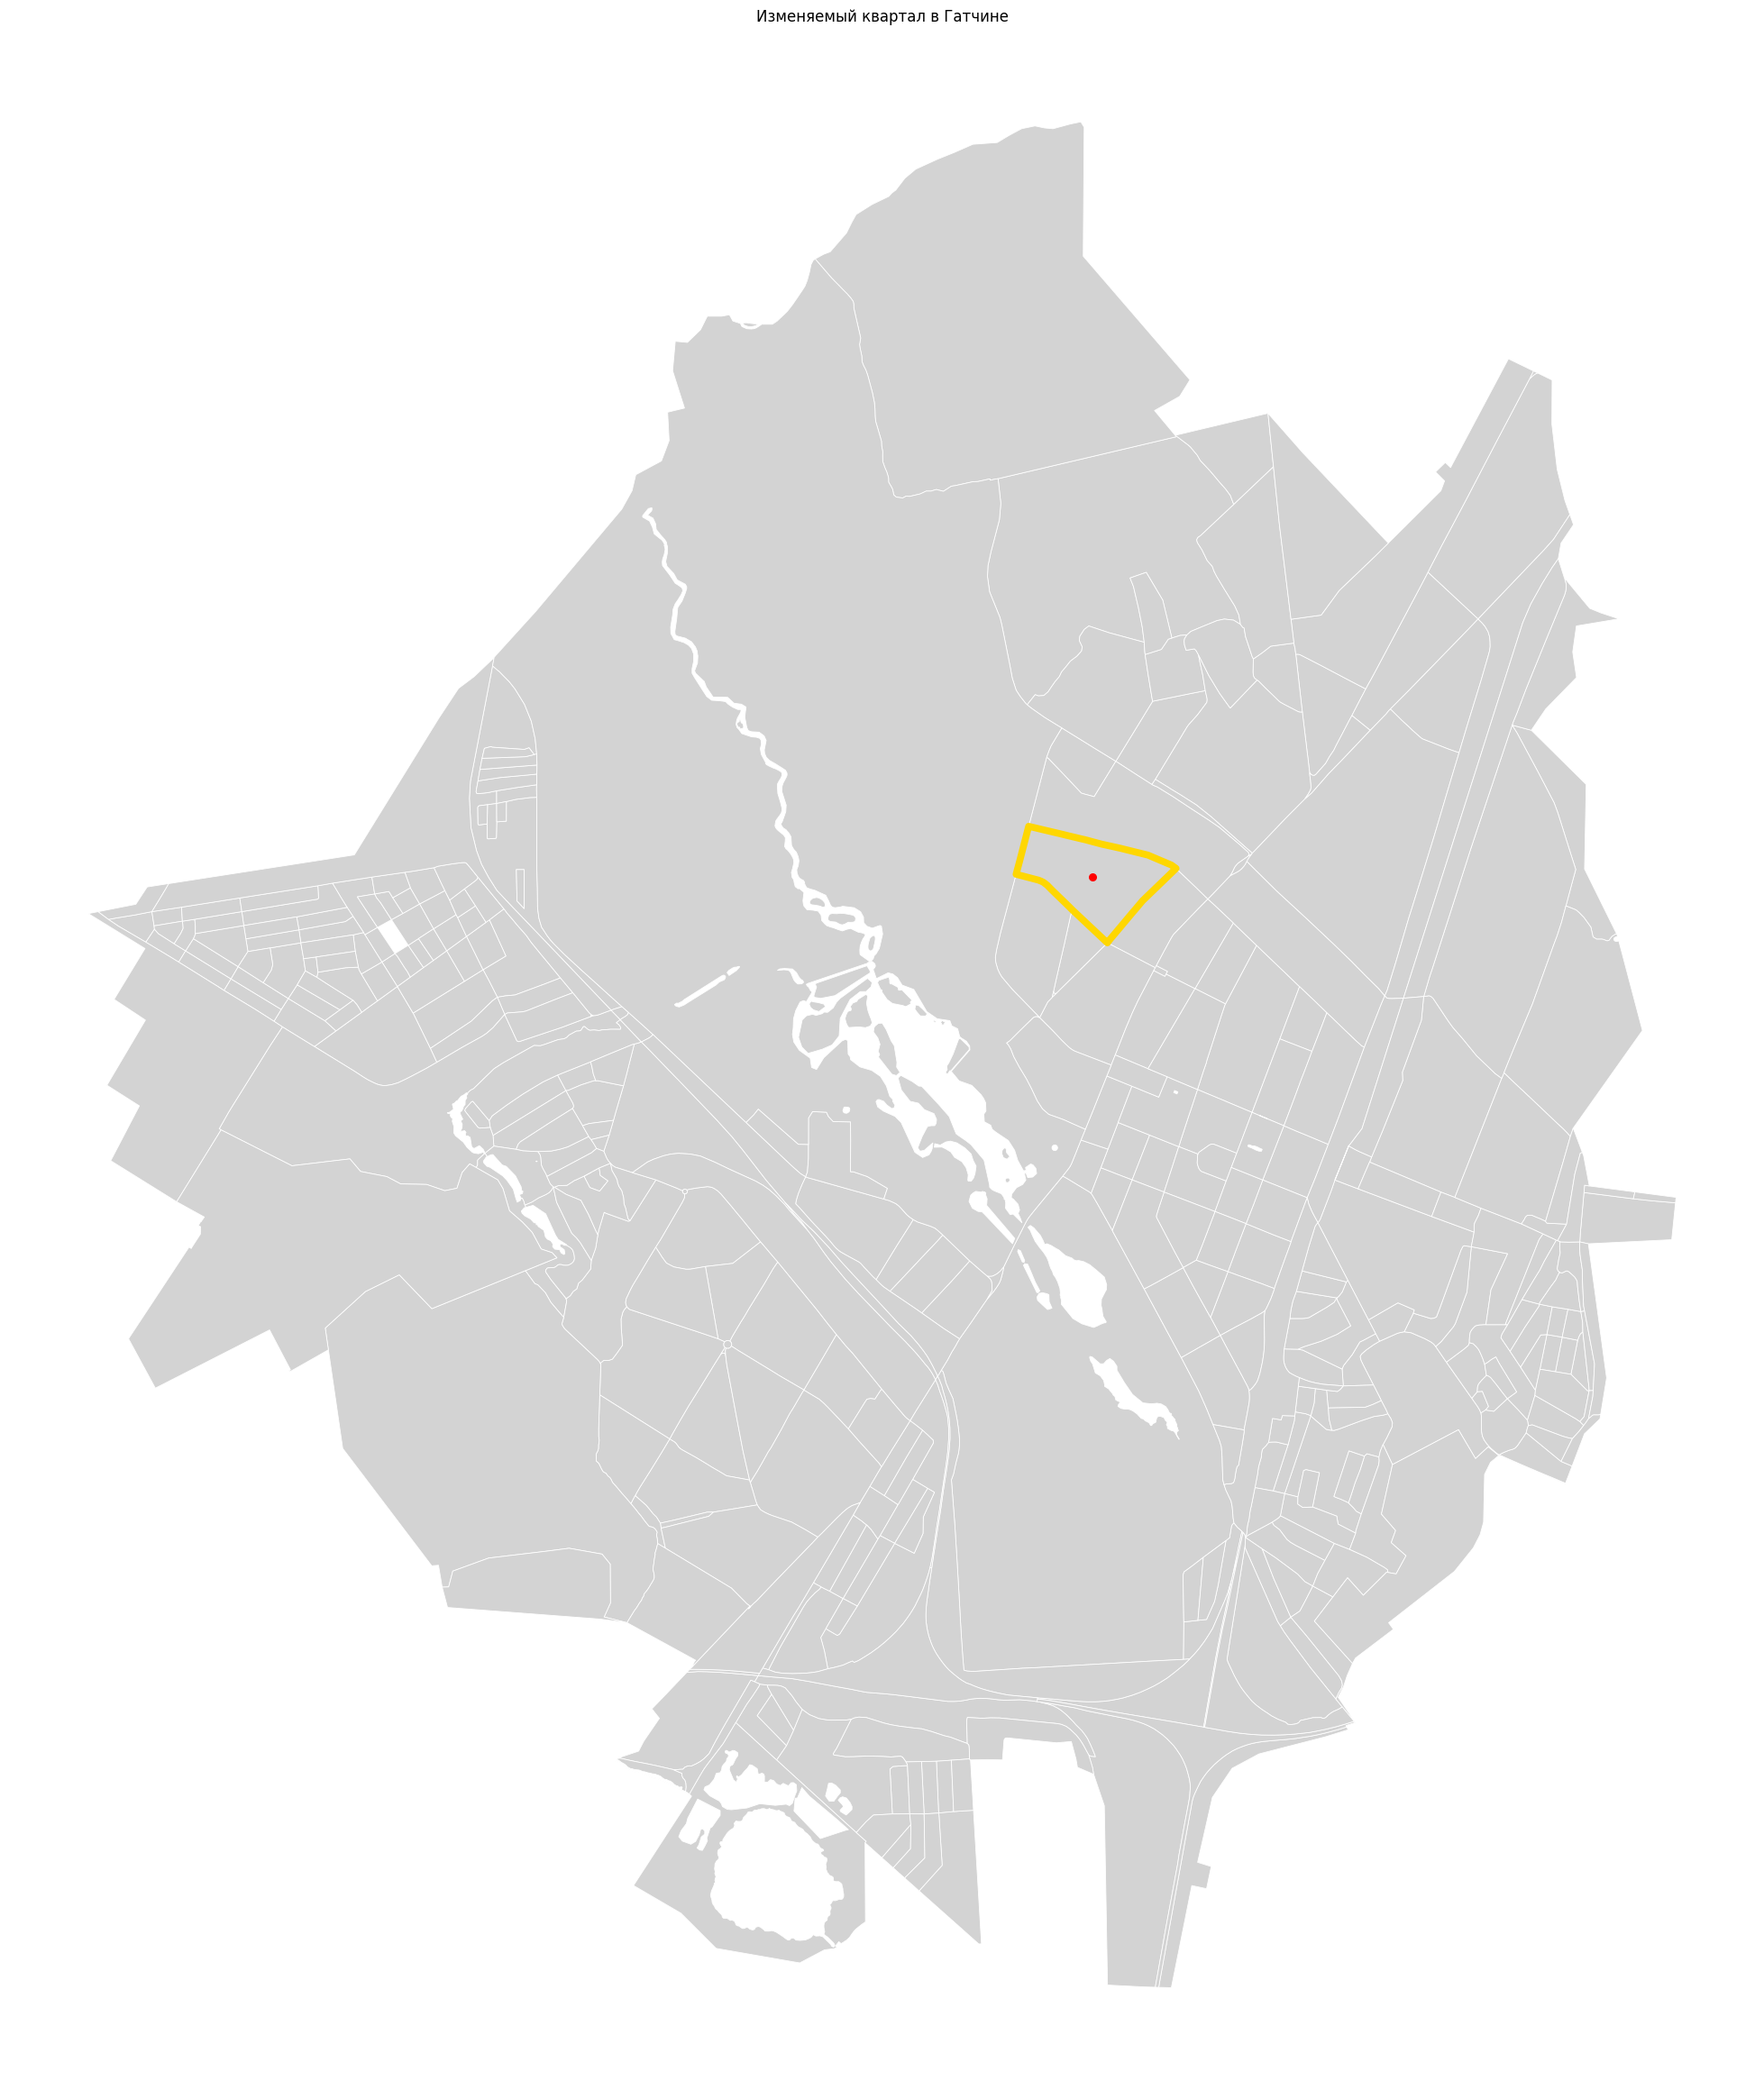

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(25, 35))
blocks_clean.plot(ax=ax, color="lightgrey", edgecolor="white", linewidth=0.6)  # фон
blocks_clean.loc[blocks_clean["id"]==87].plot(
    ax=ax, color="none", edgecolor="gold", linewidth=5.5
)
blocks_clean.loc[blocks_clean["id"]==87].centroid.plot(
     ax=ax, color="red", markersize=30, zorder=3
 )

ax.set_title("Изменяемый квартал в Гатчине")
ax.axis("off")
plt.show()

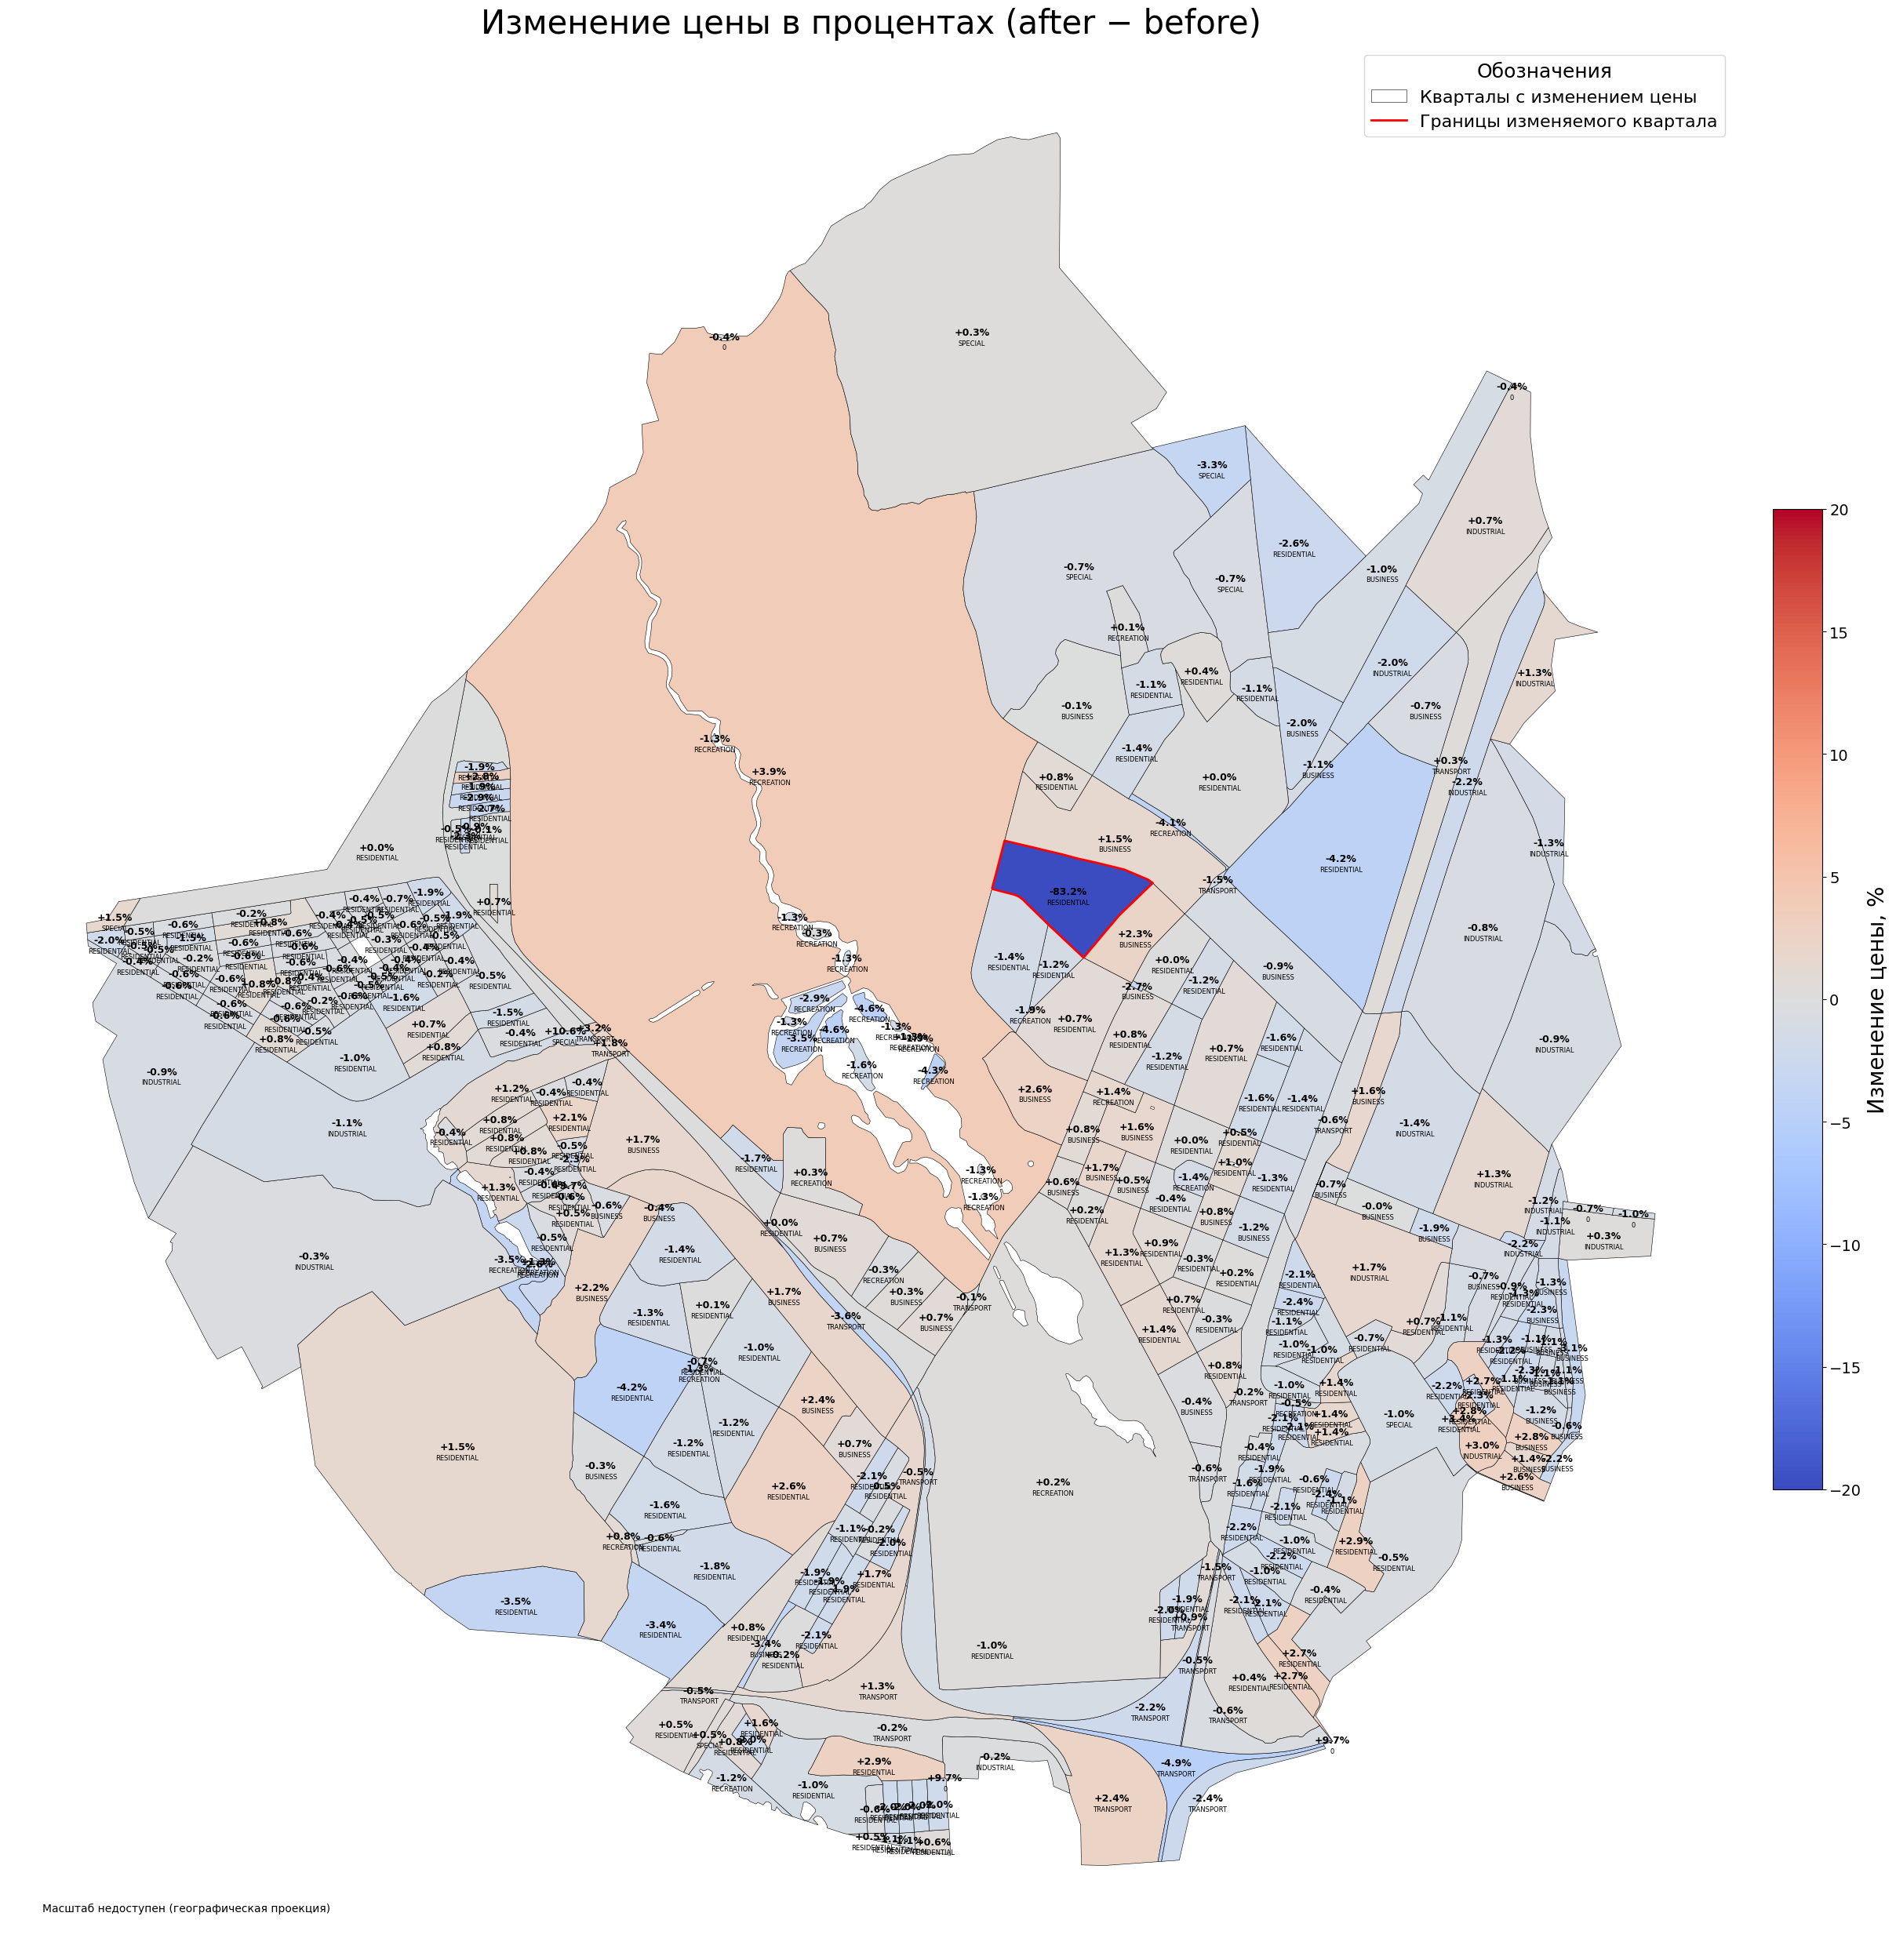


Статистика по кварталам в контексте (|Δ₽| > 1e-09):

Изменяемый квартал:
index | land_use | до (₽) → после (₽) | Δ₽ | Δ%
86 | RESIDENTIAL | 1 021 127 957 ₽ → 171 733 471 ₽ | -849 394 486 ₽ | -83.2%

Кварталы в границах проекта:
Нет кварталов проекта с изменениями выше порога.

Кварталы в контексте:
index | land_use | до (₽) → после (₽) | Δ₽ | Δ%
307 | RESIDENTIAL | 542 467 543 ₽ → 545 601 177 ₽ | +3 133 634 ₽ | +0.6%
245 | TRANSPORT | 441 378 281 ₽ → 452 046 880 ₽ | +10 668 598 ₽ | +2.4%
294 | TRANSPORT | 89 471 567 ₽ → 85 111 380 ₽ | -4 360 187 ₽ | -4.9%
114 | RESIDENTIAL | 126 078 455 ₽ → 123 581 307 ₽ | -2 497 148 ₽ | -2.0%
313 | RESIDENTIAL | 153 322 462 ₽ → 150 285 711 ₽ | -3 036 751 ₽ | -2.0%
308 | 0 | 11 678 ₽ → 12 814 ₽ | +1 137 ₽ | +9.7%
314 | INDUSTRIAL | 271 285 751 ₽ → 270 640 014 ₽ | -645 737 ₽ | -0.2%
224 | TRANSPORT | 234 910 736 ₽ → 229 781 137 ₽ | -5 129 599 ₽ | -2.2%
295 | TRANSPORT | 3 509 108 ₽ → 3 492 433 ₽ | -16 676 ₽ | -0.5%
5 | TRANSPORT | 131 169 652 ₽ → 132 3

In [13]:
from urbanomy.methods.land_value_modeling import (
    ScenarioTEPModifier,
    plot_scenario_impact,
    transfer_baseline_prices,
)

# Все снесли - ничего не осталось
blocks_after = blocks_clean.copy()
changes = {
        # Структура использования территории
        "residential": 0.0,
        "business": 0.0,
        "recreation": 0.0,
        "industrial": 0.0,
        "transport": 0.0,
        "special": 0.0,
        "agriculture": 0.0,
        "share": 1.0,

    
    "footprint_area": 0.0,   
    "build_floor_area": 0.0,  
    "living_area": 0.0,      
    "non_living_area": 0.0,  
    "population": 0.0,                

    
    "fsi": 0.0,                         
    "gsi": 0.0,                        
    "l": 0.0,                          
                    

        
        "morphotype": "low-rise non-residential",
}

target_idx = 87

modifier = ScenarioTEPModifier(blocks_after)
blocks_before = modifier.apply(target_idx, changes)

# 1) Предсказание стоимости до/после
before_estimator = LandPriceEstimator(model=model, blocks=blocks_before, use_service_features=False,)
after_estimator = LandPriceEstimator(model=model, blocks=blocks_after, use_service_features=False,)

blocks_before_pred = before_estimator.predict()
blocks_before_pred["land_value_per_100m2"] = blocks_before_pred["land_value"] / blocks_before_pred["site_area"] * 100

blocks_after_pred = after_estimator.predict()
blocks_after_pred["land_value_per_100m2"] = blocks_after_pred["land_value"] / blocks_after_pred["site_area"] * 100

blocks_full_value = transfer_baseline_prices(
    after_blocks=blocks_before_pred,
    before_blocks=blocks_after_pred,
    scenario_mode=False,
)

blocks_full_value = blocks_full_value.replace([np.inf, -np.inf], np.nan)
blocks_full_value = blocks_full_value.fillna(0)

# 3) Только визуализация и статистика по процентным изменениям
scenario_result = plot_scenario_impact(
    blocks=blocks_full_value,
    target_idx=target_idx,          
    target_id_column="id",   # если колонка называется иначе — укажи здесь
    figsize=(25, 35),
)

In [14]:
# blocks_after.to_file('./data/test/gatchina_RESIDENTIAL.geojson', driver='GeoJSON')

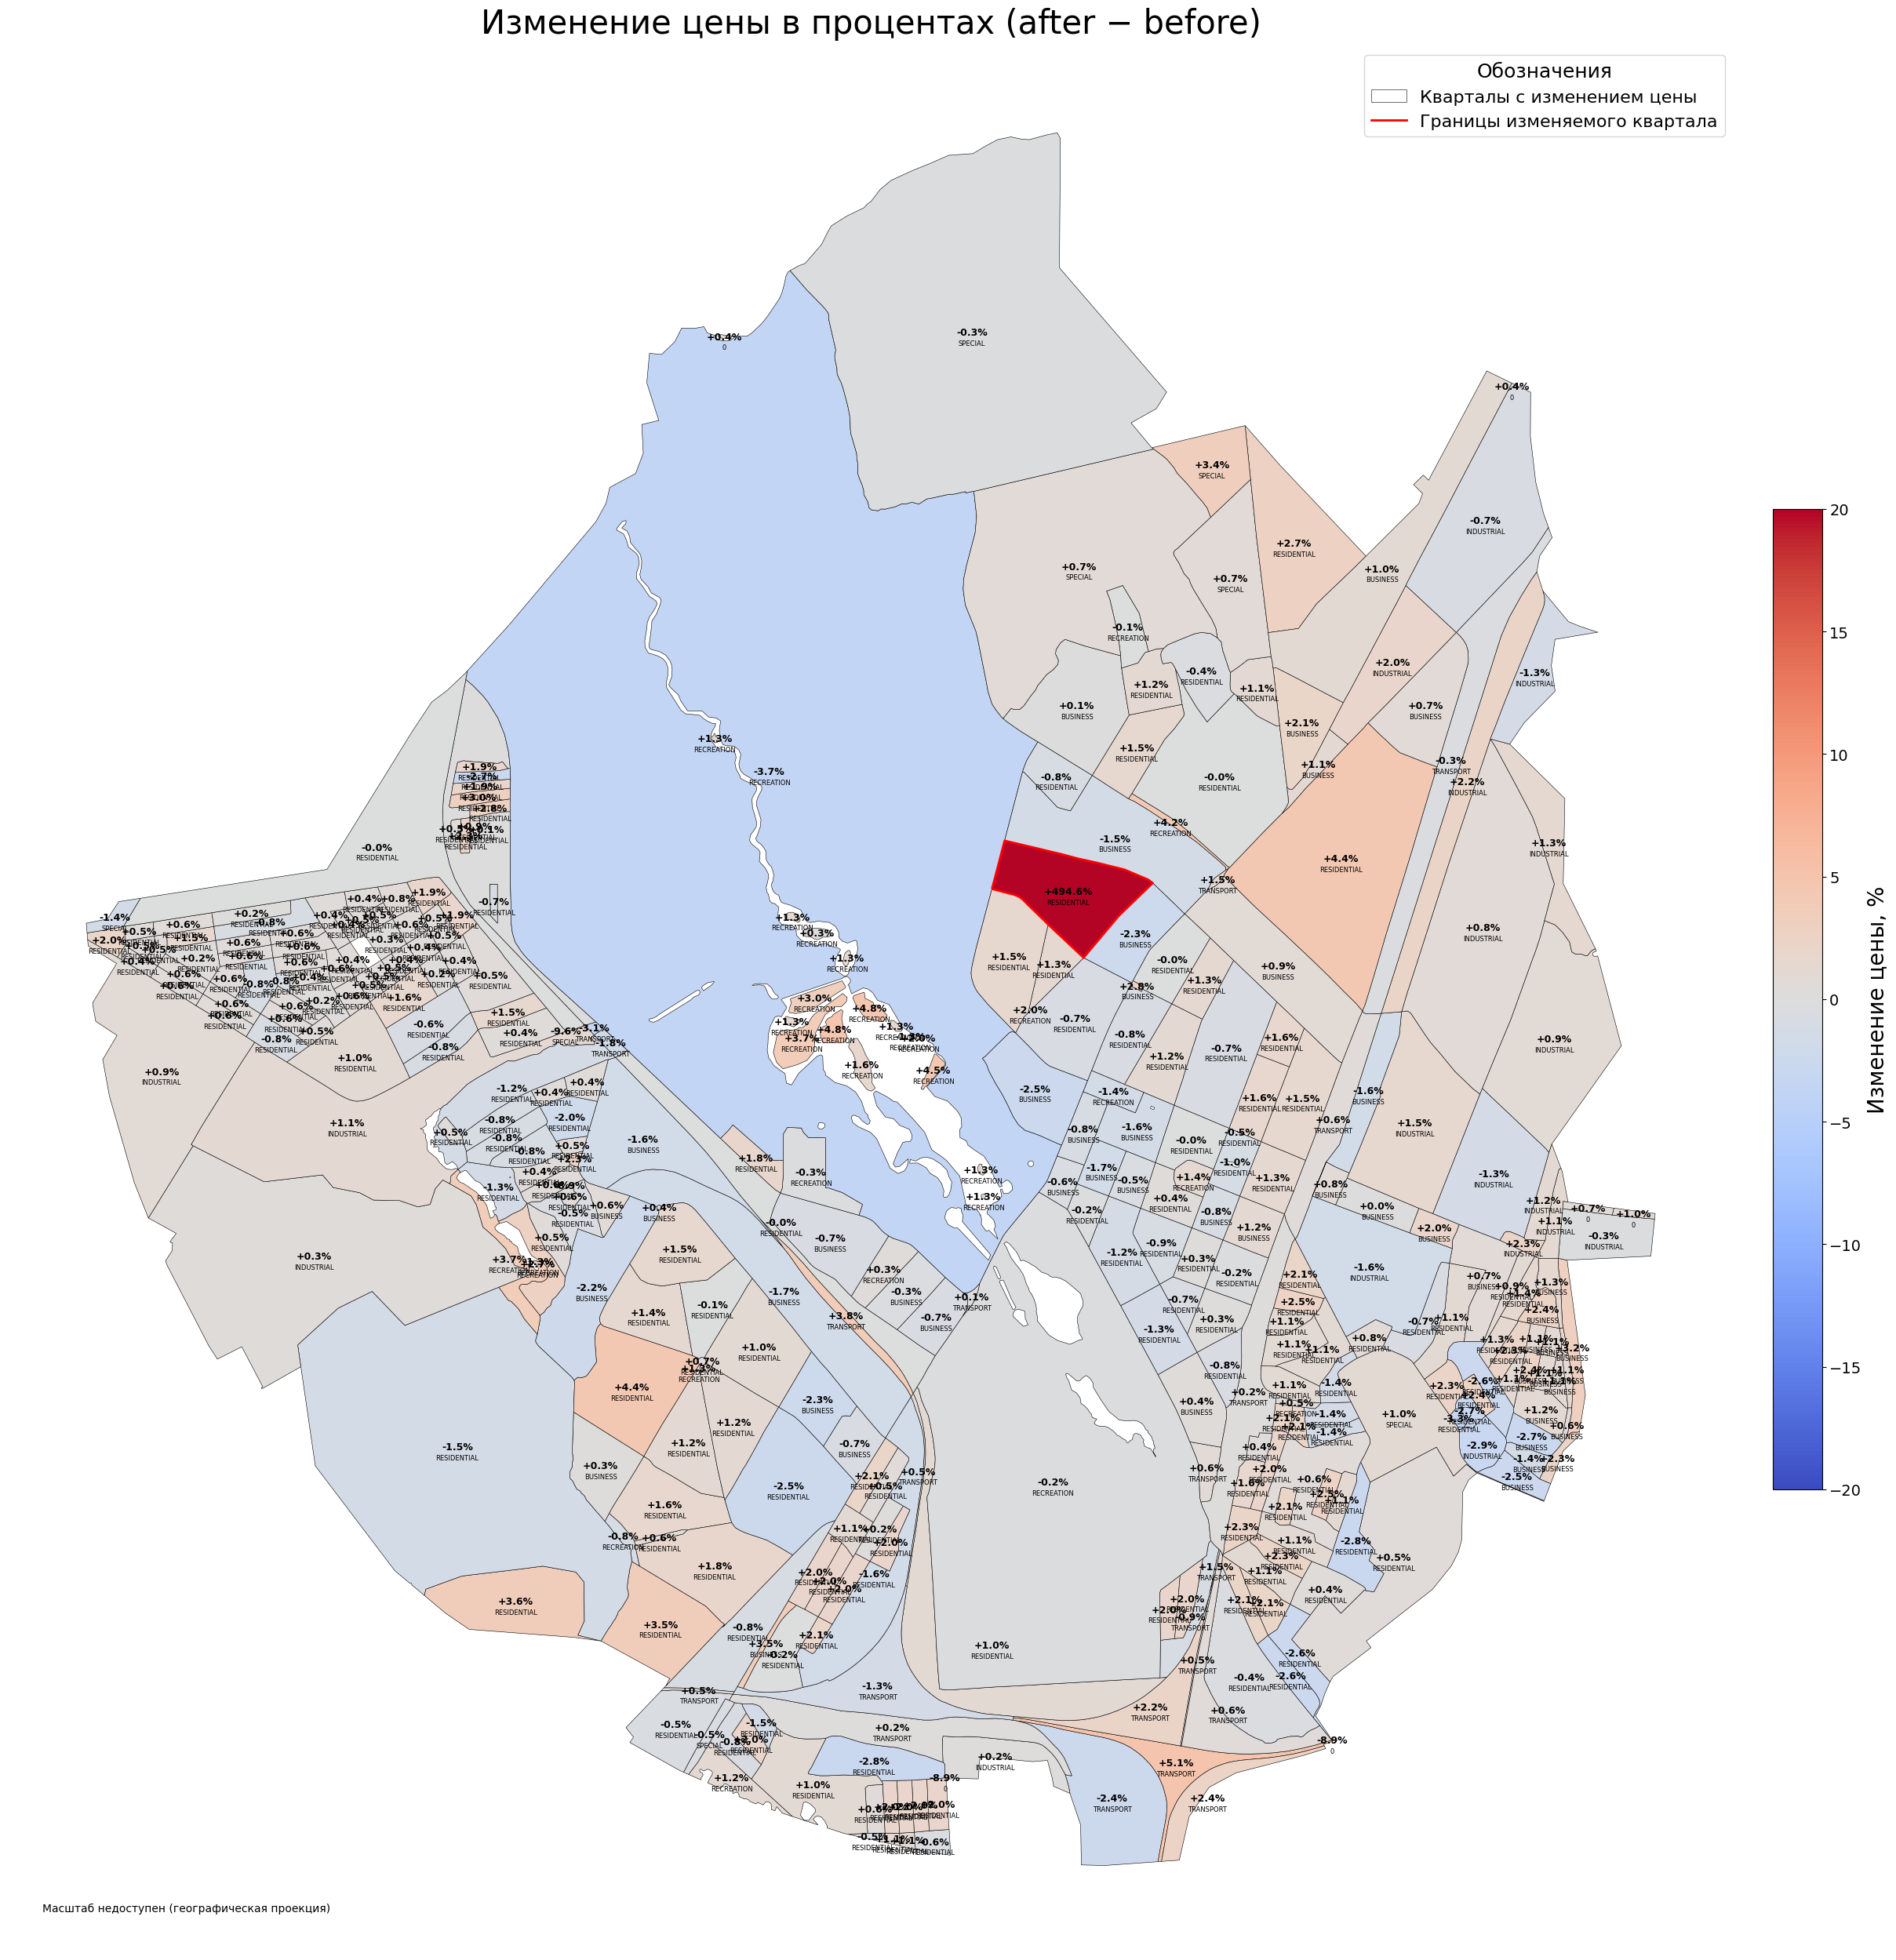


Статистика по кварталам в контексте (|Δ₽| > 1e-09):

Изменяемый квартал:
index | land_use | до (₽) → после (₽) | Δ₽ | Δ%
86 | RESIDENTIAL | 171 733 471 ₽ → 1 021 127 957 ₽ | +849 394 486 ₽ | +494.6%

Кварталы в границах проекта:
Нет кварталов проекта с изменениями выше порога.

Кварталы в контексте:
index | land_use | до (₽) → после (₽) | Δ₽ | Δ%
307 | RESIDENTIAL | 545 601 177 ₽ → 542 467 543 ₽ | -3 133 634 ₽ | -0.6%
245 | TRANSPORT | 452 046 880 ₽ → 441 378 281 ₽ | -10 668 598 ₽ | -2.4%
294 | TRANSPORT | 85 111 380 ₽ → 89 471 567 ₽ | +4 360 187 ₽ | +5.1%
114 | RESIDENTIAL | 123 581 307 ₽ → 126 078 455 ₽ | +2 497 148 ₽ | +2.0%
313 | RESIDENTIAL | 150 285 711 ₽ → 153 322 462 ₽ | +3 036 751 ₽ | +2.0%
308 | 0 | 12 814 ₽ → 11 678 ₽ | -1 137 ₽ | -8.9%
314 | INDUSTRIAL | 270 640 014 ₽ → 271 285 751 ₽ | +645 737 ₽ | +0.2%
224 | TRANSPORT | 229 781 137 ₽ → 234 910 736 ₽ | +5 129 599 ₽ | +2.2%
295 | TRANSPORT | 3 492 433 ₽ → 3 509 108 ₽ | +16 676 ₽ | +0.5%
5 | TRANSPORT | 132 305 808 ₽ → 131 

In [15]:
blocks_full_value = transfer_baseline_prices(
    after_blocks=blocks_after_pred,
    before_blocks=blocks_before_pred,
    scenario_mode=False,
)

blocks_full_value = blocks_full_value.replace([np.inf, -np.inf], np.nan)
blocks_full_value = blocks_full_value.fillna(0)

# 3) Только визуализация и статистика по процентным изменениям
scenario_result = plot_scenario_impact(
    blocks=blocks_full_value,
    target_idx=target_idx,          
    target_id_column="id",   # если колонка называется иначе — укажи здесь
    figsize=(25, 35),
)

# Оптимизация агентами!

# **Инвестиционная** привлекактельтность 

In [16]:
blocks_after = blocks_after.copy()
blocks_after["is_project"] = False
blocks_after.loc[blocks_after["id"] == target_idx, "is_project"] = True


In [17]:
from blocksnet.enums import LandUse

benchmarks_ru = {
    LandUse.RESIDENTIAL: {
        "cost_build": 45_000,
        "price_sale": 140_000,
        "construction_years": 3,
        "sale_years": 4,
        "opex_rate": 800,
        "cost_demolition": 900,  # ₽/м² ориентировочно по России
    },
    LandUse.BUSINESS: {
        "cost_build": 55_000,
        "rent_annual": 25_000,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 1_300,
        "cost_demolition": 900,
    },
    LandUse.RECREATION: {
        "cost_build": 20_000,
        "rent_annual": 7_500,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 1_000,
        "cost_demolition": 900,
    },
    LandUse.SPECIAL: {
        "cost_build": 35_000,
        "rent_annual": 11_000,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 1_500,
        "cost_demolition": 900,
    },
    LandUse.INDUSTRIAL: {
        "cost_build": 38_000,
        "rent_annual": 14_800,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 700,
        "cost_demolition": 900,
    },
    LandUse.AGRICULTURE: {
        "cost_build": 25_000,
        "rent_annual": 6_500,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 300,
        "cost_demolition": 900,
    },
    LandUse.TRANSPORT: {
        "cost_build": 18_000,
        "rent_annual": 8_200,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 600,
        "cost_demolition": 900,
    },
}


In [18]:
from urbanomy.methods.investment_potential import prepare_investment_input


potential_df = pd.read_csv("./data/gatchina/land_use_potentials.csv")

investment_input = prepare_investment_input(
    gdf = blocks_after,
    project_potential = potential_df,
)

investment_input.head()

2026-02-19 14:14:05.718 | WARNING  | urbanomy.utils.investment_input:prepare_investment_input:455 - prepare_investment_input: колонка 'land_value_before' не найдена; значения скопированы из 'land_value'.


,land_use,land_value,land_value_before,site_area,living_area,non_living_area,build_floor_area,share,spatial_potential,land_use_before
0,LandUse.RESIDENTIAL,1.066619e+09,1.066619e+09,705080.041579,132192.815395,58395.681287,190588.496682,0.690324,0.0,


In [19]:
from urbanomy.methods.investment_potential import InvestmentAttractivenessAnalyzer

an = InvestmentAttractivenessAnalyzer(benchmarks=benchmarks_ru)
summary = an.calculate_investment_metrics(investment_input, discount_rate=0.18)
summary

Project totals:
 • Land area:          705,080.04
 • Built area:         190,588.50
 • Land value:         1,066,618,958.46
 • Demolition cost:    171,529,647.01
 • Construction cost:  8,576,482,350.68
 • Investment need:    9,814,630,956.15
 • Spatial potential:  0.00
 • Project NPV:        4,191,416,222.15
 • Project IRR:        0.33
 • Project ROI:        5.19
 • Project PP (yrs):   5.38
 • Project EI:         100.00
 • Project INV score:  60.00


,land_use,land_area,land_value_before,built_area,land_value,demolition_cost,construction_cost,investment_need,NPV,IRR,ROI,PP_years,EI,spatial_potential,INV
0,LandUse.RESIDENTIAL,705080.04,1.066619e+09,190588.5,1.066619e+09,1.715296e+08,8.576482e+09,9.814631e+09,4.191416e+09,0.33,5.19,5.38,100.0,0.0,60.0


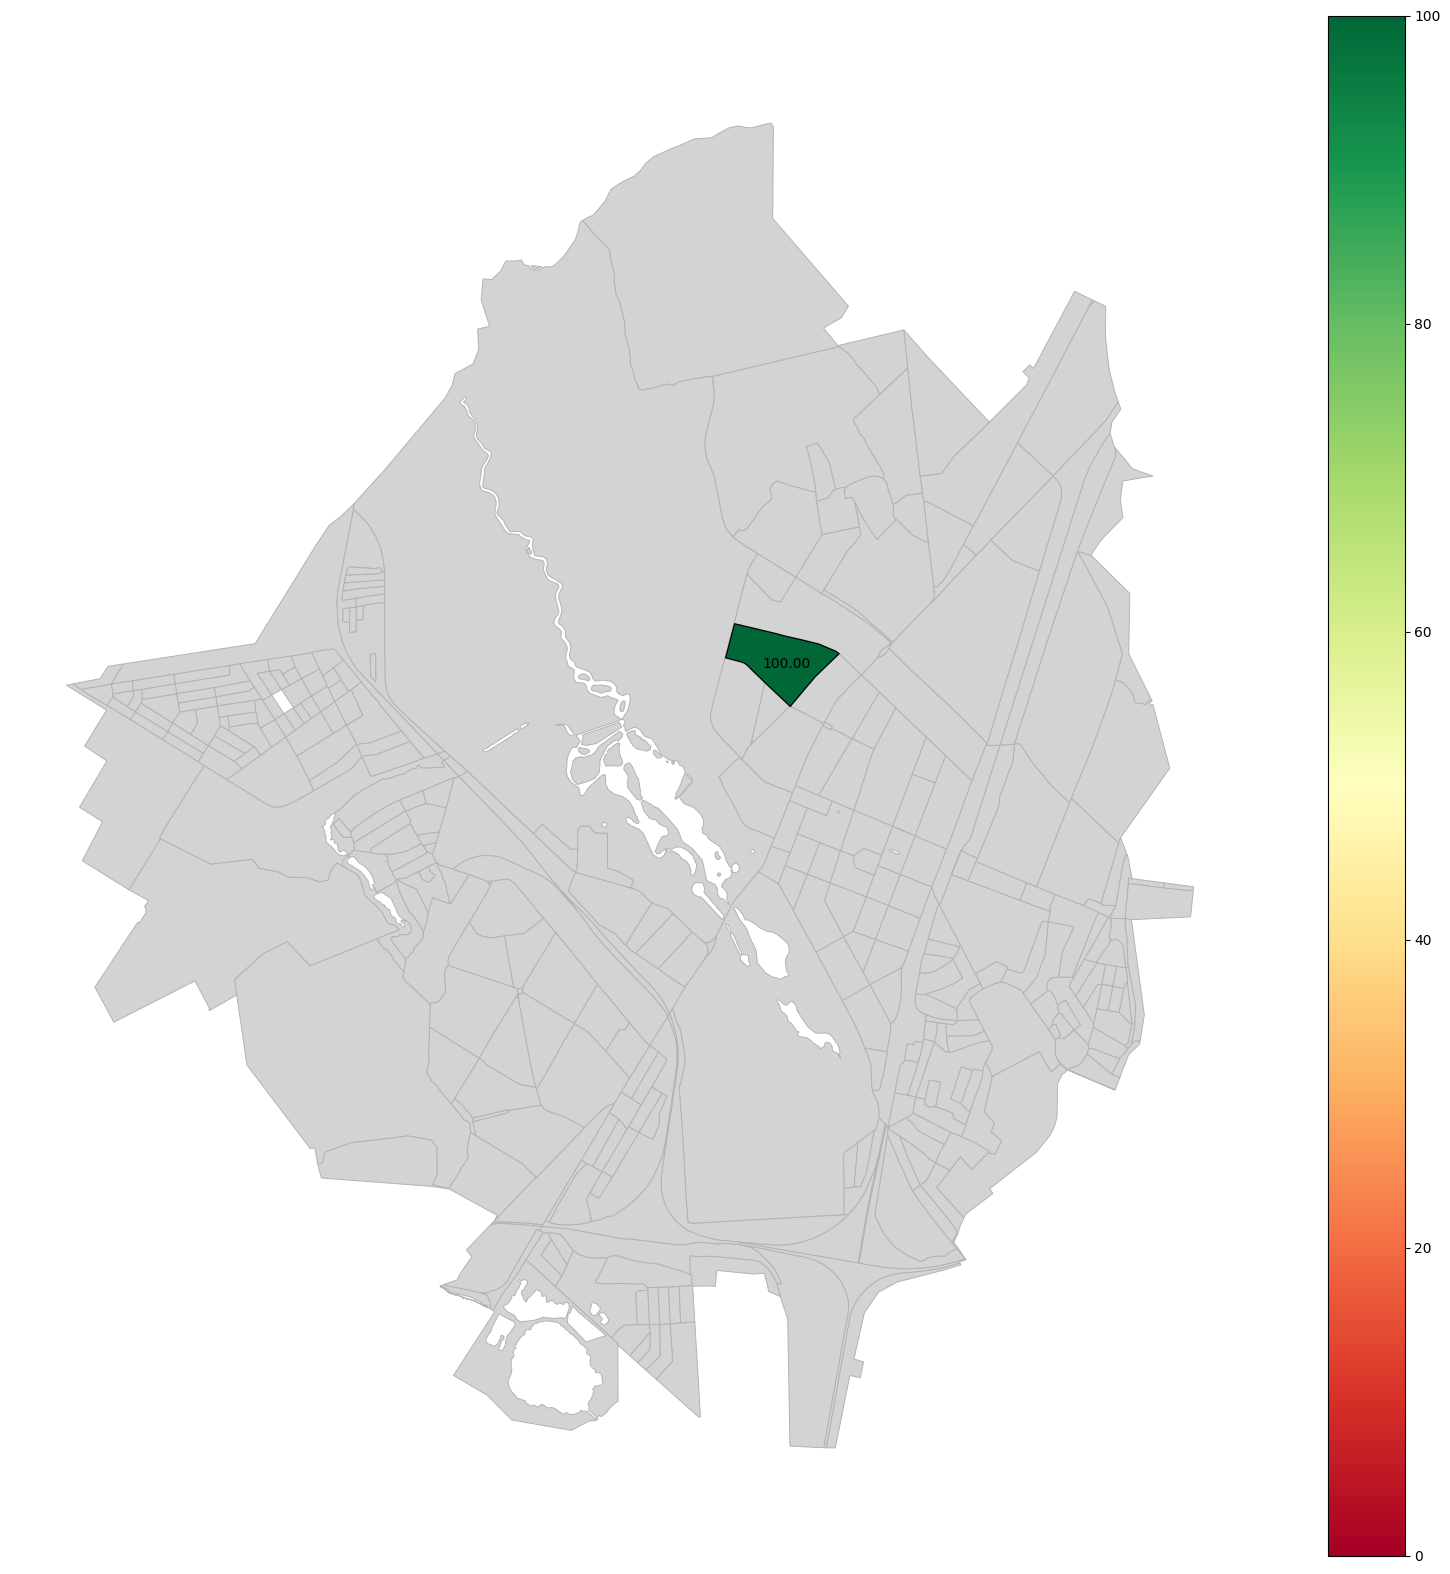

In [20]:
# 1) кладём summary на нужный индекс
summary_idxed = summary.copy()
summary_idxed.index = [target_idx]  # если одна строка; иначе set_index по id

# 2) собираем слой
scn = blocks_after[["geometry"]].join(summary_idxed, how="left")
scn["is_project"] = scn.index == target_idx

column = "EI"
vmin, vmax = 0, 100

fig, ax = plt.subplots(figsize=(20, 20))
scn.loc[~scn["is_project"]].plot(ax=ax, color="lightgrey", edgecolor="0.7", linewidth=0.7)

scn_proj = scn.loc[scn["is_project"]]
if len(scn_proj):
    scn_proj.plot(
        ax=ax,
        column=column,
        cmap="RdYlGn",
        legend=True,
        edgecolor="black",
        linewidth=0.9,
        vmin=vmin,
        vmax=vmax,
    )
    for _, row in scn_proj.dropna(subset=[column]).iterrows():
        x, y = row.geometry.representative_point().coords[0]
        ax.text(x, y, f"{row[column]:.2f}", ha="center", va="center", fontsize=10, color="black")

ax.set_axis_off()
plt.show()

In [21]:
from urbanomy.methods.socio_economic_indicators.sei_calculate import SEREstimator

deafaut_cfg = {
    "population": 300_000,
}

est = SEREstimator(deafaut_cfg) # or use project_cfg
result = est.compute(scn, pretty=True)
result

,indicator,delta_total
0,Объём инвестиций в основной капитал на душу на...,28 588
1,Валовый региональный продукт на душу населения,14 135
2,Доходы бюджета территории,514 588 941
3,Средний уровень заработной платы,0.0000
4,Износ основного фонда (тыс. руб.),244 430


## Оптимизация пустого района

In [22]:
blocks_after

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,gsi,mxi,l,morphotype,area_accessibility,geometry,land_value,land_value_per_100m2,id,is_project
0,0.690207,0.211718,0.055976,0.000000,0.042093,0.000000,0.0,LandUse.RESIDENTIAL,0.690207,7383.849525,...,0.008829,0.091908,1.371459,individual residential,10.063987,"POLYGON ((30.09367 59.55207, 30.09375 59.55215...",6.833466e+08,81712.868330,0,False
1,0.970519,0.029484,0.000000,0.000000,0.000000,0.000000,0.0,LandUse.RESIDENTIAL,0.970519,15304.958732,...,0.036428,0.712492,5.824002,mid-rise,10.210398,"POLYGON ((30.09448 59.56164, 30.09448 59.56164...",8.727378e+08,207723.484640,1,False
2,0.936589,0.010562,0.052849,0.000000,0.000000,0.000000,0.0,LandUse.RESIDENTIAL,0.936589,17141.628200,...,0.056576,0.786029,5.365401,mid-rise,8.669212,"POLYGON ((30.12546 59.58002, 30.12541 59.57998...",6.121753e+08,202047.687390,2,False
3,0.121353,0.819171,0.059489,0.000000,0.000000,0.000000,0.0,LandUse.BUSINESS,0.819171,9453.530183,...,0.075903,0.198114,2.288643,low-rise model,7.467434,"POLYGON ((30.12501 59.56588, 30.12497 59.56582...",1.809802e+08,145310.813724,3,False
4,0.068737,0.931312,0.000000,0.000000,0.000000,0.000000,0.0,LandUse.BUSINESS,0.931312,8567.309559,...,0.071648,0.095598,2.187029,low-rise model,8.285434,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,...",1.709968e+08,143003.845249,4,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
346,0.085212,0.005620,0.000000,0.042102,0.000000,0.877347,0.0,LandUse.SPECIAL,0.877347,2246.815967,...,0.002989,0.197735,1.381096,individual residential,12.661504,"POLYGON ((30.13472 59.59243, 30.13519 59.59012...",4.589715e+08,61050.872974,346,False
347,0.603114,0.000000,0.000000,0.000000,0.000000,0.392772,0.0,LandUse.RESIDENTIAL,0.603114,0.000000,...,0.000000,0.000000,0.000000,0,10.657258,"POLYGON ((30.13429 59.59456, 30.13472 59.59243...",3.994135e+08,44839.421337,347,False
348,0.921247,0.007951,0.070064,0.000000,0.000000,0.000000,0.0,LandUse.RESIDENTIAL,0.921247,0.000000,...,0.000000,0.000000,0.000000,0,10.546195,"POLYGON ((30.06949 59.54791, 30.06991 59.54711...",3.841310e+08,53989.504887,348,False
349,0.604336,0.000000,0.393593,0.000000,0.000000,0.000000,0.0,LandUse.RESIDENTIAL,0.604336,0.000000,...,0.000000,0.000000,0.000000,0,9.879099,"POLYGON ((30.084 59.5465, 30.08427 59.54673, 3...",2.374099e+08,41777.086873,349,False


In [23]:
from urbanomy.methods.land_value_modeling.ga_mc_optimizer import DistrictProblem
# теперь оптимизируем пустой район генетикой!
target_idx = 87
blocks_clean.iloc[86]
site_area = float(blocks_clean["site_area"].iloc[86])


In [ ]:
    # "residential": {"type": "float", "min": 0.0, "max": 1.0},
    # "business": {"type": "float", "min": 0.0, "max": 1.0},
    # "recreation": {"type": "float", "min": 0.0, "max": 1.0},
    # "industrial": {"type": "float", "min": 0.0, "max": 1.0},
    # "transport": {"type": "float", "min": 0.0, "max": 1.0},
    # "special": {"type": "float", "min": 0.0, "max": 1.0},
    # "agriculture": {"type": "float", "min": 0.0, "max": 1.0},

In [ ]:
problem = DistrictProblem(
    blocks=blocks_clean,
    target_idx=target_idx,
    model=model,
    benchmarks=benchmarks_ru,
    potential_df=potential_df,
    
constraints = {
    "footprint_area": {"type": "float", "min": 0.0, "max": 0.1 * site_area},
    "l": {"type": "float", "min": 1.0, "max": 15.0},
    "mxi": {"type": "float", "min": 0.0, "max": 1.0},

    "residential": {"type": "float", "min": 0.0, "max": 1.0},
    "business": {"type": "float", "min": 0.0, "max": 1.0},
    "recreation": {"type": "float", "min": 0.0, "max": 1.0},
    "industrial": {"type": "float", "min": 0.0, "max": 1.0},
},
    
    estimator_kwargs={
        "orig_features": numeric_feats+cat_features,
        "categorical_features": cat_features,
    }
)

In [42]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize

algorithm = NSGA2(
    pop_size=50,
    eliminate_duplicates=True,
)

res = minimize(
    problem,
    algorithm,
    ('n_gen', 60),
    seed=42,
    verbose=True,
    save_history=True,
)


n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       50 |     10 |             - |             -
     2 |      100 |     10 |  0.0482437524 |         ideal
     3 |      150 |      8 |  0.0280176467 |         ideal
     4 |      200 |     13 |  0.0257140160 |         ideal
     5 |      250 |     14 |  0.0055516623 |         ideal
     6 |      300 |     14 |  0.0858438975 |         ideal
     7 |      350 |     16 |  0.0280289657 |         nadir
     8 |      400 |     11 |  0.1115619552 |         ideal
     9 |      450 |     18 |  0.1090673070 |         ideal
    10 |      500 |     23 |  0.0120585614 |             f
    11 |      550 |     24 |  0.0716035291 |         ideal
    12 |      600 |     26 |  0.0059974731 |             f
    13 |      650 |     29 |  0.0170049683 |         ideal
    14 |      700 |     31 |  0.0044330079 |             f
    15 |      750 |     25 |  0.0166124896 |         ideal
    16 |      800 |     25 |  0.0233371881 |         nad

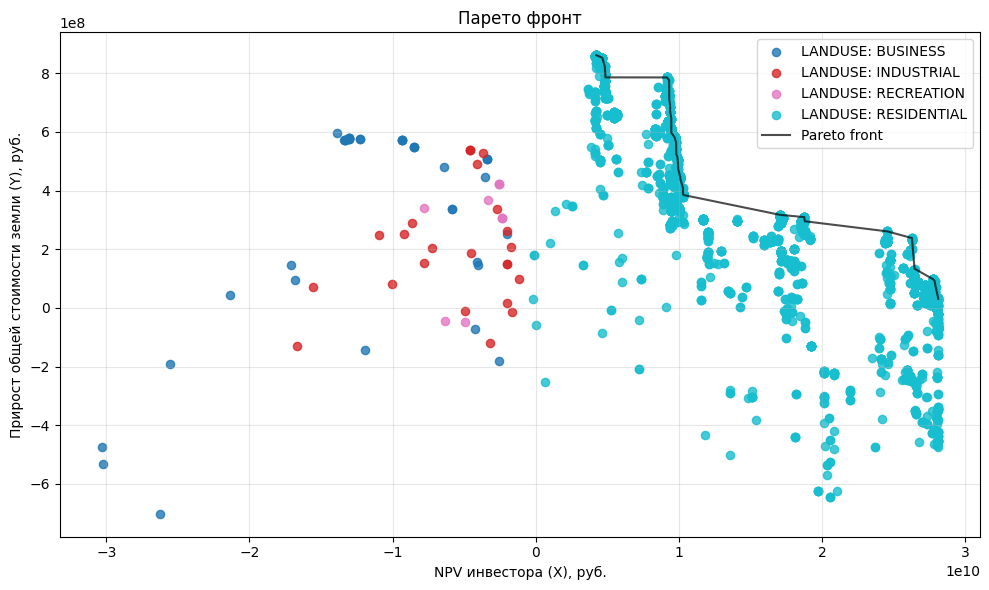

In [43]:
import numpy as np
import matplotlib.pyplot as plt

optimizer = problem

# 1) Базовая стоимость "до"
baseline_land_value = optimizer.evaluate_catboost(
    geonome=optimizer.blocks,
    model=optimizer.model,
    orig_features=optimizer.estimator_kwargs["orig_features"],
    cat_features=optimizer.estimator_kwargs["categorical_features"],
    radius_list=None,
)

# 2) Собираем ВСЕ решения: из history (если optimize(..., save_history=True)), иначе из res.X/res.F
X_all, F_all = [], []
if getattr(res, "history", None):
    for alg in res.history:
        pop = alg.pop
        Xi, Fi = pop.get("X"), pop.get("F")
        if Xi is not None and Fi is not None and len(Xi):
            X_all.append(np.asarray(Xi))
            F_all.append(np.asarray(Fi))

if X_all:
    X = np.vstack(X_all)
    F = np.vstack(F_all)
else:
    X = np.asarray(res.X)
    F = np.asarray(res.F)

# 3) Цели
land_value_total = -F[:, 0]
admin_gain = land_value_total - baseline_land_value
investor_npv = -F[:, 1]

# 4) LANDUSE для каждого решения (через тот же repair, что в оптимизаторе)
landuse_labels = []
for genome_vec in X:
    changes = {name: genome_vec[j] for j, name in enumerate(optimizer.var_names)}
    repaired = optimizer._repair_genome(changes)   # использует логику из вашей задачи
    lu = repaired["land_use"]
    lu_name = getattr(lu, "name", str(lu).split(".")[-1])
    landuse_labels.append(lu_name)

landuse_labels = np.array(landuse_labels)
unique_lu = np.unique(landuse_labels)

# 5) Цвета + легенда
cmap = plt.get_cmap("tab10", len(unique_lu))
color_map = {lu: cmap(i) for i, lu in enumerate(unique_lu)}

plt.figure(figsize=(10, 6))

for lu in unique_lu:
    m = landuse_labels == lu
    plt.scatter(
        investor_npv[m],
        admin_gain[m],
        s=35,
        alpha=0.8,
        color=color_map[lu],
        label=f"LANDUSE: {lu}",
    )

# (опционально) поверх — линия самого Pareto-фронта из res.F
pf_x = -res.F[:, 1]
pf_y = -res.F[:, 0] - baseline_land_value
order = np.argsort(pf_x)
plt.plot(pf_x[order], pf_y[order], color="black", lw=1.5, alpha=0.7, label="Pareto front")

plt.xlabel("NPV инвестора (X), руб.")
plt.ylabel("Прирост общей стоимости земли (Y), руб.")
plt.title("Парето фронт")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()   


In [27]:
print("Лучшие решения (переменные):\n", res.X) # Массив решений на фронте Парето
print("Значения целевых функций:\n", -res.F)


Лучшие решения (переменные):
 [[2.57527019e+04 1.49346151e+01 4.92360579e-01 9.21641784e-01
  2.10448706e-01 1.94017853e-01 5.11036620e-02 9.12332472e-01
  7.13262417e-02 5.03236691e-05]
 [2.78636178e+04 9.34756612e+00 8.07104428e-01 9.49897604e-01
  7.77658125e-02 1.93746494e-01 5.11481394e-02 9.09934178e-01
  5.85363445e-01 3.24746244e-05]
 [2.33935213e+04 7.71405679e+00 8.41193108e-01 1.95371906e-01
  5.82951085e-02 1.75391119e-01 4.69822611e-02 9.11685911e-01
  6.31972468e-02 1.32230538e-05]
 [6.34130216e+04 9.49764992e+00 8.07094245e-01 9.47491653e-01
  2.10853450e-01 1.93521276e-01 4.59888484e-03 9.25217178e-01
  1.37572202e-01 3.58638403e-05]
 [2.18655558e+04 1.04052151e+01 7.97038326e-01 9.60574981e-01
  7.18003275e-02 2.06494720e-01 1.01109480e-03 8.73052506e-01
  5.57887221e-01 2.01302424e-05]
 [2.78636178e+04 9.34756612e+00 8.07104428e-01 9.48056683e-01
  7.65223899e-02 1.93746494e-01 5.11397844e-02 9.09934178e-01
  5.85239411e-01 3.24746244e-05]
 [2.56673984e+04 9.34756612e

In [28]:
len(res.opt)

31

In [ ]:
# for i, opt in enumerate(res.opt):
#     params = {name: opt.X[j] for j, name in enumerate(problem.var_names)}
#     params = problem._repair_genome(params)
#     plot_scenario_impact(
#         blocks_before=blocks_after,
#         blocks_after=ScenarioTEPModifier(blocks_after).apply(target_idx, params),
#         orig_features=numeric_feats+cat_features,
#         categorical_features=cat_features,
#         model=model,
#         target_idx=target_idx,
#         figsize=(25, 35),
#     )
#     print(f"Решение {i}:")
#     print("Переменные (геном):", opt.X)
#     print("Целевые функции:", -opt.F)
#     print("-" * 30)

In [44]:
import numpy as np

# т.к. F минимизируется, а ты пишешь F[:,0] = -land_value
idx_city = np.argmin(res.F[:, 0])   # максимум land_value
params_optimal = {p: res.X[idx_city][i] for i, p in enumerate(problem.constraints.keys())}
params_optimal

{'footprint_area': np.float64(14962.80866418418),
 'l': np.float64(12.855114710805312),
 'mxi': np.float64(0.8626312581009474),
 'residential': np.float64(0.9199973127138308),
 'business': np.float64(0.4228174892285061),
 'recreation': np.float64(0.5897793981888787),
 'industrial': np.float64(0.8530211091700597)}

In [31]:
params_optimal = {param: res.X[3][i] for i, param in enumerate(problem.constraints.keys())}
params_optimal

{'footprint_area': np.float64(63413.02155615421),
 'l': np.float64(9.497649915105193),
 'mxi': np.float64(0.8070942446914965),
 'residential': np.float64(0.9474916530067967),
 'business': np.float64(0.21085344979133608),
 'recreation': np.float64(0.1935212757216618),
 'industrial': np.float64(0.004598884842120555),
 'transport': np.float64(0.925217177939665),
 'special': np.float64(0.13757220187928523),
 'agriculture': np.float64(3.5863840343640145e-05)}

In [45]:
params_repaired = problem._repair_genome(params_optimal)
params_repaired

{'footprint_area': 14962.80866418418,
 'l': 12.855114710805312,
 'mxi': 0.8626312581009474,
 'residential': 0.33026717998064015,
 'business': 0.15178603011575303,
 'recreation': 0.21172320392538874,
 'industrial': 0.30622358597821814,
 'transport': 0.0,
 'special': 0.0,
 'agriculture': 0.0,
 'share': 0.33026717998064015,
 'land_use': <LandUse.RESIDENTIAL: 'residential'>,
 'build_floor_area': 192348.62177391924,
 'living_area': 165925.93359481925,
 'non_living_area': 26422.68817909999,
 'population': 8296.296679740963,
 'fsi': 0.2728039519360529,
 'gsi': 0.021221432719441134,
 'morphotype': 'high-rise soviet microdistrict'}

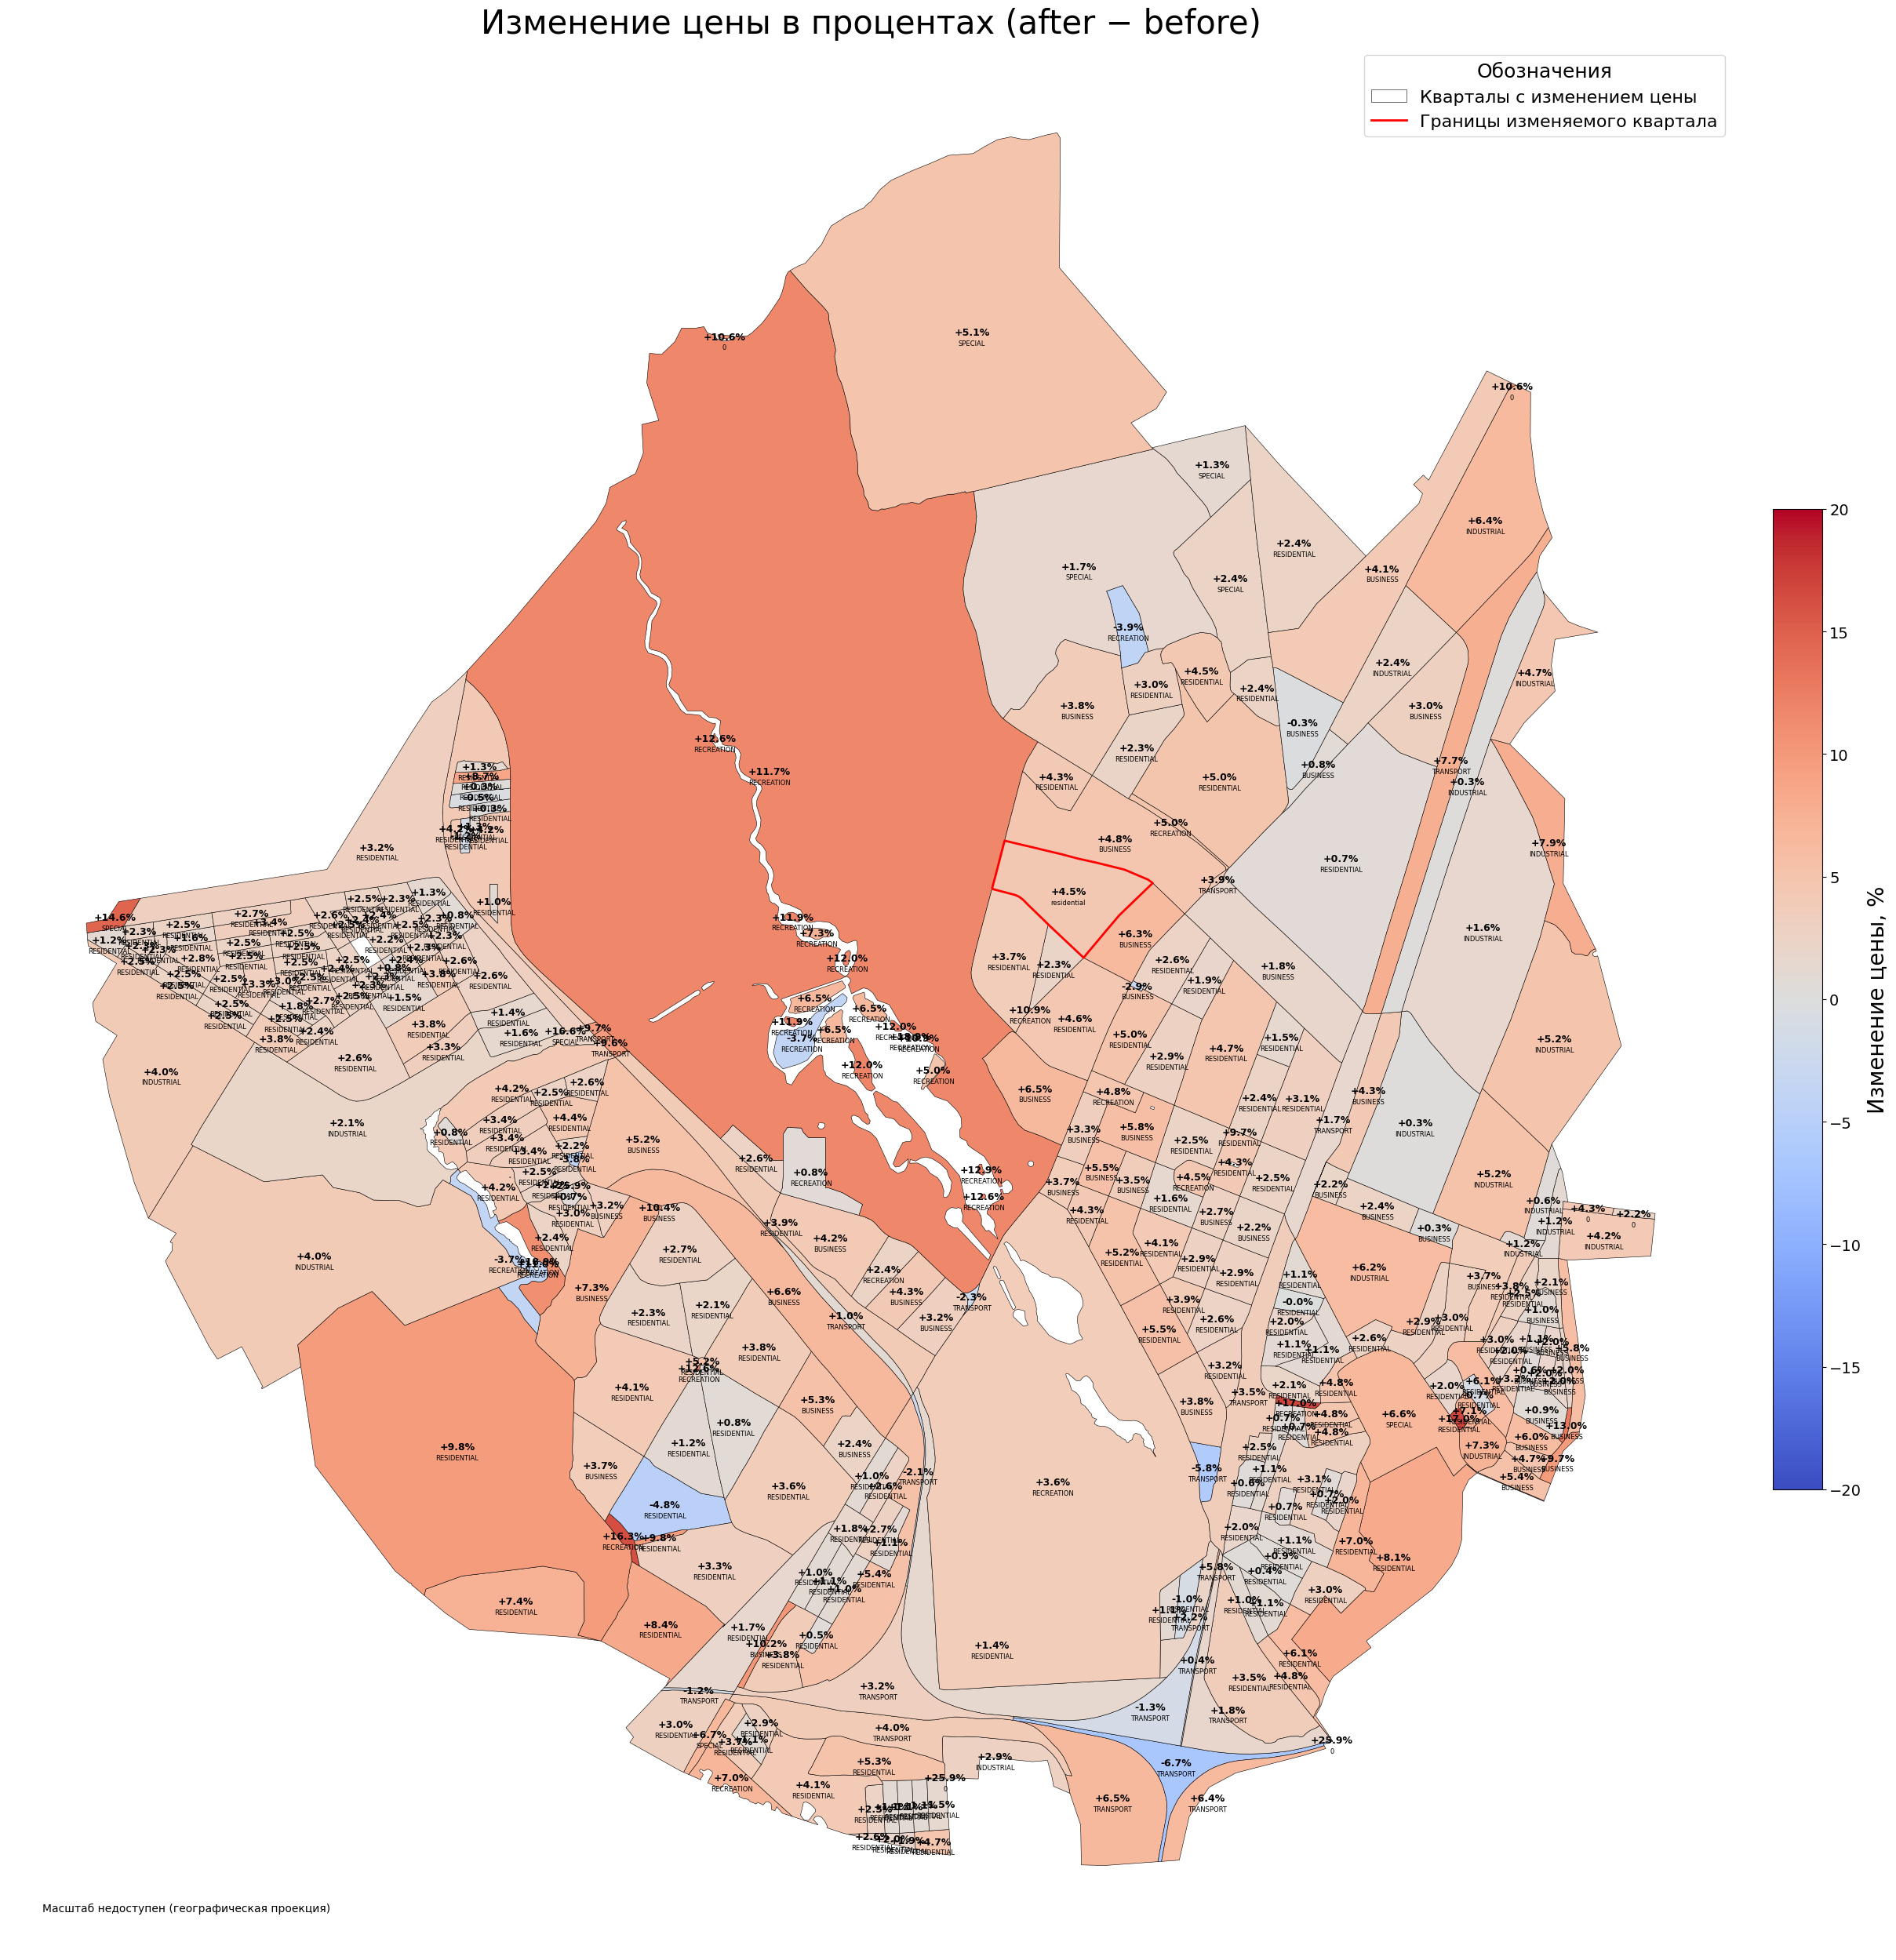


Статистика по кварталам в контексте (|Δ₽| > 1e-09):

Изменяемый квартал:
index | land_use | до (₽) → после (₽) | Δ₽ | Δ%
86 | residential | 1 021 127 957 ₽ → 1 066 618 958 ₽ | +45 491 002 ₽ | +4.5%

Кварталы в границах проекта:
Нет кварталов проекта с изменениями выше порога.

Кварталы в контексте:
index | land_use | до (₽) → после (₽) | Δ₽ | Δ%
307 | RESIDENTIAL | 542 467 543 ₽ → 568 220 429 ₽ | +25 752 886 ₽ | +4.7%
245 | TRANSPORT | 441 378 281 ₽ → 470 108 239 ₽ | +28 729 957 ₽ | +6.5%
294 | TRANSPORT | 89 471 567 ₽ → 83 519 164 ₽ | -5 952 403 ₽ | -6.7%
114 | RESIDENTIAL | 126 078 455 ₽ → 127 433 496 ₽ | +1 355 041 ₽ | +1.1%
313 | RESIDENTIAL | 153 322 462 ₽ → 155 658 890 ₽ | +2 336 428 ₽ | +1.5%
308 | 0 | 11 678 ₽ → 14 703 ₽ | +3 025 ₽ | +25.9%
314 | INDUSTRIAL | 271 285 751 ₽ → 279 176 632 ₽ | +7 890 881 ₽ | +2.9%
224 | TRANSPORT | 234 910 736 ₽ → 231 854 941 ₽ | -3 055 795 ₽ | -1.3%
295 | TRANSPORT | 3 509 108 ₽ → 3 524 255 ₽ | +15 147 ₽ | +0.4%
5 | TRANSPORT | 131 169 652 ₽ → 1

In [47]:
blocks_full_value = transfer_baseline_prices(
    after_blocks=modifier.apply(target_idx, params_repaired),
    before_blocks=blocks_after_pred,
    scenario_mode=False,
)

blocks_full_value = blocks_full_value.replace([np.inf, -np.inf], np.nan)
blocks_full_value = blocks_full_value.fillna(0)

# 3) Только визуализация и статистика по процентным изменениям
scenario_result = plot_scenario_impact(
    blocks=blocks_full_value,
    target_idx=target_idx,          
    target_id_column="id",   # если колонка называется иначе — укажи здесь
    figsize=(25, 35),
)

In [48]:
import pandas as pd

blocks_gen = modifier.apply(target_idx, params_repaired)   # без запятой

gen_blocks = pd.DataFrame(blocks_gen)

gen_blocks.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,mxi,l,morphotype,area_accessibility,geometry,land_value,land_value_per_100m2,id,share_living,share_non_living
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,7383.849525,...,0.091908,1.371459,individual residential,10.063987,"POLYGON ((30.09367 59.55207, 30.09375 59.55215...",6.833466e+08,81712.868330,0,NaN,NaN
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,15304.958732,...,0.712492,5.824002,mid-rise,10.210398,"POLYGON ((30.09448 59.56164, 30.09448 59.56164...",8.727378e+08,207723.484640,1,NaN,NaN
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,17141.628200,...,0.786029,5.365401,mid-rise,8.669212,"POLYGON ((30.12546 59.58002, 30.12541 59.57998...",6.121753e+08,202047.687390,2,NaN,NaN
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,9453.530183,...,0.198114,2.288643,low-rise model,7.467434,"POLYGON ((30.12501 59.56588, 30.12497 59.56582...",1.809802e+08,145310.813724,3,NaN,NaN
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,8567.309559,...,0.095598,2.187029,low-rise model,8.285434,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,...",1.709968e+08,143003.845249,4,NaN,NaN


In [49]:
gen_blocks.iloc[86]

residential                                                      0.330267
business                                                         0.151786
recreation                                                       0.211723
industrial                                                       0.306224
transport                                                             0.0
special                                                               0.0
agriculture                                                           0.0
land_use                                              LandUse.RESIDENTIAL
share                                                            0.330267
footprint_area                                               14962.808664
build_floor_area                                            192348.621774
living_area                                                 165925.933595
non_living_area                                              26422.688179
population                            

In [51]:
blocks_after.iloc[86]

residential                                                      0.690324
business                                                         0.219805
recreation                                                       0.089872
industrial                                                            0.0
transport                                                             0.0
special                                                               0.0
agriculture                                                           0.0
land_use                                              LandUse.RESIDENTIAL
share                                                            0.690324
footprint_area                                               33119.603537
build_floor_area                                            190588.496682
living_area                                                 132192.815395
non_living_area                                              58395.681287
population                            

In [52]:
gen_blocks = gen_blocks.copy()
gen_blocks["is_project"] = False

# target_idx — индекс изменяемого квартала
if target_idx in gen_blocks.index:
    gen_blocks.loc[target_idx, "is_project"] = True
else:
    raise KeyError(f"target_idx={target_idx} не найден в gen_blocks.index")

investment_input = prepare_investment_input(
    gdf=gen_blocks,
    project_potential=potential_df,
)

summary = an.calculate_investment_metrics(
    investment_input,
    discount_rate=0.18,
    show_project_totals=True
)
summary

2026-02-19 17:10:34.724 | WARNING  | urbanomy.utils.investment_input:prepare_investment_input:455 - prepare_investment_input: колонка 'land_value_before' не найдена; значения скопированы из 'land_value'.


Project totals:
 • Land area:          705,080.04
 • Built area:         192,348.62
 • Land value:         1,066,618,958.46
 • Demolition cost:    173,113,759.60
 • Construction cost:  8,655,687,979.83
 • Investment need:    9,895,420,697.88
 • Spatial potential:  0.00
 • Project NPV:        4,239,975,289.55
 • Project IRR:        0.33
 • Project ROI:        5.20
 • Project PP (yrs):   5.37
 • Project EI:         100.00
 • Project INV score:  60.00


,land_use,land_area,land_value_before,built_area,land_value,demolition_cost,construction_cost,investment_need,NPV,IRR,ROI,PP_years,EI,spatial_potential,INV
0,LandUse.RESIDENTIAL,705080.04,1.066619e+09,192348.62,1.066619e+09,173113759.6,8.655688e+09,9.895421e+09,4.239975e+09,0.33,5.2,5.37,100.0,0.0,60.0


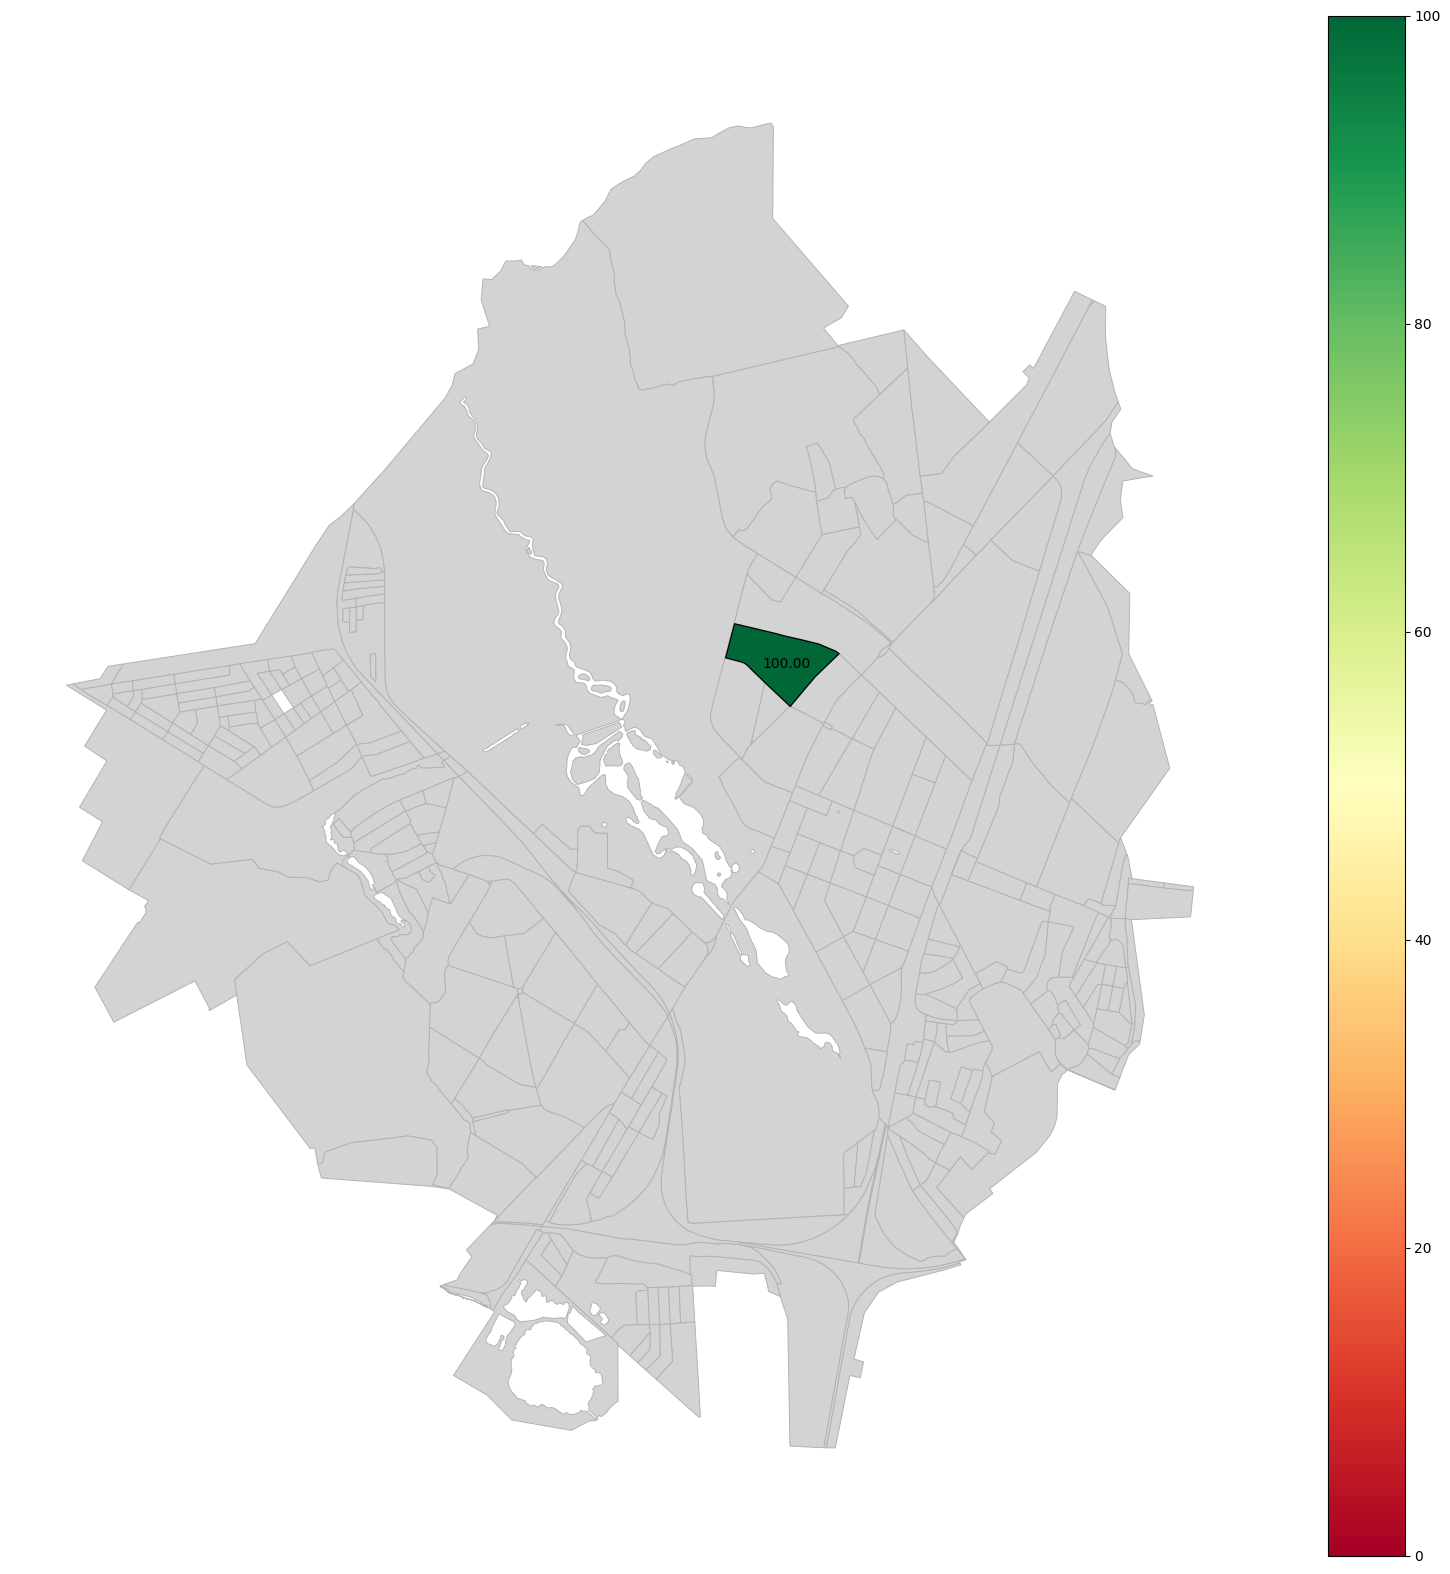

In [53]:
# 1) кладём summary на нужный индекс
summary_idxed = summary.copy()
summary_idxed.index = [target_idx]  # если одна строка; иначе set_index по id

# 2) собираем слой
scn = blocks_after[["geometry"]].join(summary_idxed, how="left")
scn["is_project"] = scn.index == target_idx

column = "EI"
vmin, vmax = 0, 100

fig, ax = plt.subplots(figsize=(20, 20))
scn.loc[~scn["is_project"]].plot(ax=ax, color="lightgrey", edgecolor="0.7", linewidth=0.7)

scn_proj = scn.loc[scn["is_project"]]
if len(scn_proj):
    scn_proj.plot(
        ax=ax,
        column=column,
        cmap="RdYlGn",
        legend=True,
        edgecolor="black",
        linewidth=0.9,
        vmin=vmin,
        vmax=vmax,
    )
    for _, row in scn_proj.dropna(subset=[column]).iterrows():
        x, y = row.geometry.representative_point().coords[0]
        ax.text(x, y, f"{row[column]:.2f}", ha="center", va="center", fontsize=10, color="black")

ax.set_axis_off()
plt.show()

In [54]:
from urbanomy.methods.socio_economic_indicators.sei_calculate import SEREstimator

deafaut_cfg = {
    "population": 300_000,
}

est = SEREstimator(deafaut_cfg) # or use project_cfg
result = est.compute(scn, pretty=True)
result

,indicator,delta_total
0,Объём инвестиций в основной капитал на душу на...,28 852
1,Валовый региональный продукт на душу населения,14 266
2,Доходы бюджета территории,519 341 279
3,Средний уровень заработной платы,0.0000
4,Износ основного фонда (тыс. руб.),246 687
